# AI Usage Analysis — Team Project

We are working as a **team** and opening **five scenarios** to analyze student AI usage, study behavior, and academic performance. Each scenario uses a consistent pipeline so results are easy to compare and present together.

## Scenarios

| # | Focus | Notebook / artifact |
|---|--------|-------------------|
| **1** | Usage patterns, cleaning, charts, automation alerts | `student-ai-usage-analysis.ipynb` (this notebook) |
| **2** | *Team to define* | Planned |
| **3** | *Team to define* | Planned |
| **4** | *Team to define* | Planned |
| **5** | *Team to define* | Planned |

---

# Scenario 1 — Student AI Usage Analysis

Structured notebook pipeline:

| Section | Description |
|---------|-------------|
| Dataset description | Source file, columns, and derived fields |
| Data loading | Read CSV and explore shape |
| Data cleaning | Missing values, duplicates, imputation |
| Analysis | Usage patterns and performance metrics |
| Visualizations | Charts saved to `output/` |
| Automation logic | Alert rules and `Alert_Status` |
| Results | Processed data, PNG gallery, HTML report |

---

## Dataset description

**File:** `ai_impact_student_performance_dataset.csv`  
**Records:** 8,000 students · **Columns:** 26

### Key columns

| Column | Description |
|--------|-------------|
| `student_id`, `age`, `gender`, `grade_level` | Student demographics |
| `uses_ai`, `ai_usage_time_minutes`, `ai_tools_used` | AI adoption and tools |
| `ai_usage_purpose`, `ai_dependency_score`, `ai_prompts_per_week` | How and how often AI is used |
| `study_hours_per_day`, `attendance_percentage`, `study_consistency_index` | Study behavior |
| `last_exam_score`, `assignment_scores_avg`, `final_score`, `passed` | Academic outcomes |
| `performance_category` | Low / Medium / High |

### Derived fields (created during cleaning)

- `academic_year` — from `grade_level`
- `subscription_type` — Free / Basic / Premium from `ai_dependency_score`
- `session_duration_minutes` — usage time ÷ weekly prompts
- `missed_deadlines` — proxy from consistency and attendance
- `age_group` — binned age ranges
- `Alert_Status` — automation alerts (Automation logic section)


In [1]:
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display

%matplotlib inline

DATASET_PATH = Path("ai_impact_student_performance_dataset.csv")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

AI_USAGE_THRESHOLD = 120
ACADEMIC_PERFORMANCE_THRESHOLD = 50
MISSED_DEADLINES_THRESHOLD = 3
FRESHMAN_LOW_USAGE_THRESHOLD = 40
GRADE_ORDER = ["10th", "11th", "12th", "1st Year", "2nd Year", "3rd Year"]
AGE_BINS = [0, 16, 18, 21, 25, 100]
AGE_LABELS = ["Under 16", "16-17", "18-20", "21-24", "25+"]

CHART_TITLES = {
    "01_usage_by_academic_year.png": "01 — Average AI usage by academic year",
    "02_subscription_distribution.png": "02 — Subscription distribution",
    "03_usage_vs_performance.png": "03 — AI usage vs academic performance",
    "04_year_vs_usage_frequency_heatmap.png": "04 — Academic year vs usage frequency",
    "05_usage_trends.png": "05 — AI usage trends",
    "06_summary_dashboard.png": "06 — Summary dashboard",
    "07_alert_counts.png": "07 — Alert counts",
    "08_alert_distribution.png": "08 — Alert distribution",
    "09_automation_dashboard.png": "09 — Automation dashboard",
}

def show_png_gallery(files):
    for fname in files:
        path = OUTPUT_DIR / fname
        if not path.is_file():
            print(f"Missing (run prior cells first): {path}")
            continue
        display(Markdown(f"### {CHART_TITLES.get(fname, fname)}"))
        display(Image(filename=str(path)))


In [2]:
def load_dataset(filepath: Path | str) -> tuple[pd.DataFrame, dict]:
    """Read CSV with pandas and print exploratory summaries."""
    path = Path(filepath)
    if not path.is_file():
        raise FileNotFoundError(f"Dataset not found: {path.resolve()}")

    df = pd.read_csv(path)

    print("=" * 60)
    print("1. DATASET LOAD")
    print("=" * 60)
    print(f"File: {path.resolve()}")
    print("\nFirst 5 rows:")
    print(df.head())
    print("\nColumn names:")
    print(list(df.columns))
    print("\nDataset info:")
    df.info()
    print("\nBasic statistics:")
    print(df.describe())

    meta = {
        "rows": len(df),
        "columns": list(df.columns),
        "column_count": len(df.columns),
        "missing_total": int(df.isnull().sum().sum()),
        "preview_html": df.head().to_html(classes="data-table", index=False),
        "describe_html": df.describe().round(2).to_html(classes="data-table"),
    }
    return df, meta

def clean_dataset(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """Check missing values, drop duplicates, and impute nulls where needed."""
    print("\n" + "=" * 60)
    print("2. DATA CLEANING")
    print("=" * 60)

    print("\nMissing values per column:")
    missing = df.isnull().sum()
    print(missing[missing > 0] if missing.any() else "No missing values found.")

    duplicates_before = int(df.duplicated().sum())
    print(f"\nDuplicate rows: {duplicates_before}")
    df = df.drop_duplicates()
    print(f"Rows after removing duplicates: {len(df)}")

    # Impute remaining nulls: numeric → median, categorical → mode
    for col in df.columns:
        if df[col].isnull().any():
            if pd.api.types.is_numeric_dtype(df[col]):
                df[col] = df[col].fillna(df[col].median())
            else:
                df[col] = df[col].fillna(df[col].mode().iloc[0])

    print("Cleaning complete.")
    meta = {
        "duplicates_removed": duplicates_before,
        "rows_after_clean": len(df),
        "missing_note": "No missing values"
        if missing.sum() == 0
        else missing[missing > 0].to_dict(),
    }
    return df, meta

def add_derived_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add derived fields used in analysis and automation.
    Raw CSV has no subscription, session, or deadline columns — we derive proxies.
    """
    df = df.copy()

    # Map grade_level to academic year label used in reports
    df["academic_year"] = df["grade_level"]

    # Subscription tier from AI dependency (1–10 scale in dataset)
    df["subscription_type"] = pd.cut(
        df["ai_dependency_score"],
        bins=[0, 3, 6, 10],
        labels=["Free", "Basic", "Premium"],
        include_lowest=True,
    ).astype(str)

    # Estimated minutes per AI session (usage time / weekly prompts)
    df["session_duration_minutes"] = df["ai_usage_time_minutes"] / np.clip(
        df["ai_prompts_per_week"], 1, None
    )

    # Missed-deadlines proxy: low consistency + low attendance → higher count
    df["missed_deadlines"] = np.clip(
        np.round((10 - df["study_consistency_index"]) / 2)
        + np.round((100 - df["attendance_percentage"]) / 25),
        0,
        10,
    ).astype(int)

    # Age groups for segmentation
    df["age_group"] = pd.cut(
        df["age"], bins=AGE_BINS, labels=AGE_LABELS, right=False
    )

    return df

def perform_analysis(df: pd.DataFrame) -> dict:
    """Run aggregations and print key findings."""
    print("\n" + "=" * 60)
    print("3. ANALYSIS")
    print("=" * 60)

    results = {}

    # Average AI usage time by academic year
    usage_by_year = (
        df.groupby("academic_year", observed=True)["ai_usage_time_minutes"]
        .mean()
        .reindex([g for g in GRADE_ORDER if g in df["academic_year"].unique()])
    )
    results["usage_by_year"] = usage_by_year
    print("\nAverage AI usage time (minutes) by academic year:")
    print(usage_by_year.round(2))

    # Most used AI tools
    tool_counts = df["ai_tools_used"].value_counts()
    results["tool_counts"] = tool_counts
    print("\nMost used AI tools:")
    print(tool_counts.head(10))

    # AI usage by age group
    usage_by_age = df.groupby("age_group", observed=True)["ai_usage_time_minutes"].mean()
    results["usage_by_age"] = usage_by_age
    print("\nAverage AI usage by age group:")
    print(usage_by_age.round(2))

    # Subscription distribution
    sub_dist = df["subscription_type"].value_counts()
    results["subscription_dist"] = sub_dist
    print("\nSubscription type distribution:")
    print(sub_dist)

    # Average session duration
    avg_session = df["session_duration_minutes"].mean()
    results["avg_session"] = avg_session
    print(f"\nAverage session duration (minutes): {avg_session:.2f}")

    # Purpose of AI usage
    purpose_dist = df["ai_usage_purpose"].value_counts()
    results["purpose_dist"] = purpose_dist
    print("\nAI usage purpose distribution:")
    print(purpose_dist)

    # AI usage vs academic performance
    perf_corr = df["ai_usage_time_minutes"].corr(df["final_score"])
    results["perf_corr"] = perf_corr
    print(f"\nCorrelation (AI usage minutes vs final_score): {perf_corr:.4f}")

    usage_vs_perf = df.groupby("performance_category", observed=True)[
        "ai_usage_time_minutes"
    ].mean()
    results["usage_vs_perf"] = usage_vs_perf
    print("\nAverage AI usage by performance category:")
    print(usage_vs_perf.round(2))

    # Usage trends: mean usage by academic progression (proxy trend)
    trend = usage_by_year.copy()
    results["usage_trend"] = trend
    print("\nUsage trend (by academic year order):")
    print(trend.round(2))

    return results

def _build_alert_status(row: pd.Series) -> str:
    """Apply automation rules for a single student row."""
    alerts = []

    if row["ai_usage_time_minutes"] > AI_USAGE_THRESHOLD:
        alerts.append("High AI Usage")

    if row["final_score"] < ACADEMIC_PERFORMANCE_THRESHOLD:
        alerts.append("Academic Support Needed")

    if row["missed_deadlines"] > MISSED_DEADLINES_THRESHOLD:
        alerts.append("Reminder")

    if (
        row["academic_year"] == "1st Year"
        and row["ai_usage_time_minutes"] < FRESHMAN_LOW_USAGE_THRESHOLD
    ):
        alerts.append("Tutorial Suggestion")

    return "; ".join(alerts) if alerts else "No Alert"

def apply_automation_rules(df: pd.DataFrame) -> pd.DataFrame:
    """
    Evaluate business rules and populate Alert_Status.

    Rules:
      - AI usage > threshold          → High AI Usage
      - Academic performance < threshold → Academic Support Needed
      - Missed deadlines > threshold   → Reminder
      - Freshman (1st Year) low usage    → Tutorial Suggestion
    """
    print("\n" + "=" * 60)
    print("5. AUTOMATION RULES")
    print("=" * 60)

    df = df.copy()
    df["Alert_Status"] = df.apply(_build_alert_status, axis=1)

    alert_counts = df["Alert_Status"].str.split("; ").explode().value_counts()
    print("\nAlert counts (including combined statuses):")
    print(alert_counts)

    return df

def _series_to_rows(series: pd.Series) -> list[list]:
    """Convert a pandas Series to table rows for HTML."""
    rows = []
    for idx, val in series.items():
        label = str(idx) if pd.notna(idx) else "—"
        if isinstance(val, float):
            rows.append([label, f"{val:.2f}"])
        else:
            rows.append([label, str(val)])
    return rows

def _rows_to_html_table(headers: list[str], rows: list[list]) -> str:
    """Build a simple HTML table from headers and rows."""
    head = "".join(f"<th>{h}</th>" for h in headers)
    body = "".join(
        "<tr>" + "".join(f"<td>{cell}</td>" for cell in row) + "</tr>" for row in rows
    )
    return f'<table class="data-table"><thead><tr>{head}</tr></thead><tbody>{body}</tbody></table>'

def generate_html_report(
    df: pd.DataFrame,
    results: dict,
    load_meta: dict,
    clean_meta: dict,
    dataset_name: str,
    open_browser: bool = True,
) -> Path:
    """
    Build a single-page HTML report with all terminal statistics and charts.
    Open in the browser so you can review results without scrolling the terminal.
    """
    alert_exploded = (
        df["Alert_Status"].str.split("; ").explode().replace("No Alert", np.nan).dropna()
    )
    alert_counts = alert_exploded.value_counts()
    students_with_alerts = int((df["Alert_Status"] != "No Alert").sum())
    no_alert = int((df["Alert_Status"] == "No Alert").sum())

    chart_files = [
        ("Usage by academic year", "01_usage_by_academic_year.png"),
        ("Subscription distribution", "02_subscription_distribution.png"),
        ("AI usage vs performance", "03_usage_vs_performance.png"),
        ("Year vs usage frequency", "04_year_vs_usage_frequency_heatmap.png"),
        ("Usage trends", "05_usage_trends.png"),
        ("Summary dashboard", "06_summary_dashboard.png"),
        ("Alert counts", "07_alert_counts.png"),
        ("Alert distribution", "08_alert_distribution.png"),
        ("Automation dashboard", "09_automation_dashboard.png"),
    ]
    gallery = "".join(
        f'<figure class="chart-card"><img src="{fname}" alt="{title}"/>'
        f'<figcaption>{title}</figcaption></figure>'
        for title, fname in chart_files
    )

    usage_year_rows = _series_to_rows(results["usage_by_year"])
    tool_rows = [[k, str(v)] for k, v in results["tool_counts"].head(8).items()]
    age_rows = _series_to_rows(results["usage_by_age"])
    sub_rows = [[k, str(v)] for k, v in results["subscription_dist"].items()]
    purpose_rows = [[k, str(v)] for k, v in results["purpose_dist"].items()]
    perf_rows = _series_to_rows(results["usage_vs_perf"])
    trend_rows = _series_to_rows(results["usage_trend"])
    alert_rows = [[k, str(v)] for k, v in alert_counts.items()]

    generated = datetime.now().strftime("%Y-%m-%d %H:%M")

    html = f"""<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="utf-8"/>
  <meta name="viewport" content="width=device-width, initial-scale=1"/>
  <title>AI Usage Analysis — Results</title>
  <style>
    :root {{
      --bg: #0f1419;
      --surface: #1a2332;
      --text: #e7ecf3;
      --muted: #8b9cb3;
      --accent: #3d8bfd;
      --border: #2a3548;
      --success: #3dd68c;
      --warn: #f5a623;
    }}
    * {{ box-sizing: border-box; }}
    body {{
      margin: 0;
      font-family: "Segoe UI", system-ui, sans-serif;
      background: var(--bg);
      color: var(--text);
      line-height: 1.5;
    }}
    .wrap {{ max-width: 1200px; margin: 0 auto; padding: 2rem 1.5rem 4rem; }}
    h1 {{ font-size: 1.75rem; margin: 0 0 0.25rem; font-weight: 600; }}
    .subtitle {{ color: var(--muted); margin-bottom: 2rem; font-size: 0.95rem; }}
    h2 {{
      font-size: 1.15rem;
      margin: 2.5rem 0 1rem;
      padding-bottom: 0.5rem;
      border-bottom: 1px solid var(--border);
      color: var(--accent);
    }}
    .kpi-grid {{
      display: grid;
      grid-template-columns: repeat(auto-fit, minmax(140px, 1fr));
      gap: 1rem;
      margin-bottom: 2rem;
    }}
    .kpi {{
      background: var(--surface);
      border: 1px solid var(--border);
      border-radius: 8px;
      padding: 1rem 1.1rem;
    }}
    .kpi .val {{ font-size: 1.5rem; font-weight: 600; }}
    .kpi .lbl {{ font-size: 0.8rem; color: var(--muted); margin-top: 0.25rem; }}
    .section {{
      background: var(--surface);
      border: 1px solid var(--border);
      border-radius: 8px;
      padding: 1.25rem 1.5rem;
      margin-bottom: 1rem;
    }}
    .data-table {{
      width: 100%;
      border-collapse: collapse;
      font-size: 0.88rem;
    }}
    .data-table th, .data-table td {{
      border: 1px solid var(--border);
      padding: 0.45rem 0.65rem;
      text-align: left;
    }}
    .data-table th {{ background: #243044; color: var(--muted); }}
    .two-col {{ display: grid; grid-template-columns: 1fr 1fr; gap: 1rem; }}
    @media (max-width: 800px) {{ .two-col {{ grid-template-columns: 1fr; }} }}
    .gallery {{
      display: grid;
      grid-template-columns: repeat(auto-fit, minmax(320px, 1fr));
      gap: 1.25rem;
      margin-top: 1rem;
    }}
    .chart-card {{
      margin: 0;
      background: var(--surface);
      border: 1px solid var(--border);
      border-radius: 8px;
      overflow: hidden;
    }}
    .chart-card img {{ width: 100%; display: block; }}
    .chart-card figcaption {{
      padding: 0.6rem 0.9rem;
      font-size: 0.85rem;
      color: var(--muted);
    }}
    .pill {{
      display: inline-block;
      padding: 0.2rem 0.55rem;
      border-radius: 4px;
      font-size: 0.8rem;
      background: #243044;
      color: var(--success);
      margin-right: 0.35rem;
    }}
    ul.rules {{ margin: 0; padding-left: 1.2rem; color: var(--muted); font-size: 0.9rem; }}
    .scroll-table {{ overflow-x: auto; }}
  </style>
</head>
<body>
  <div class="wrap">
    <h1>AI Usage Analysis — Overall Results</h1>
    <p class="subtitle">Generated {generated} · Source: {dataset_name} · Same output as <code>python ai_usage_analysis.py</code></p>

    <div class="kpi-grid">
      <div class="kpi"><div class="val">{load_meta['rows']:,}</div><div class="lbl">Students (raw)</div></div>
      <div class="kpi"><div class="val">{clean_meta['rows_after_clean']:,}</div><div class="lbl">After cleaning</div></div>
      <div class="kpi"><div class="val">{load_meta['column_count']}</div><div class="lbl">Columns</div></div>
      <div class="kpi"><div class="val">{df['ai_usage_time_minutes'].mean():.1f}</div><div class="lbl">Avg AI usage (min)</div></div>
      <div class="kpi"><div class="val">{df['final_score'].mean():.1f}</div><div class="lbl">Avg final score</div></div>
      <div class="kpi"><div class="val">{(df['uses_ai']==1).mean()*100:.1f}%</div><div class="lbl">Use AI</div></div>
      <div class="kpi"><div class="val">{results['perf_corr']:.3f}</div><div class="lbl">Usage vs score (r)</div></div>
      <div class="kpi"><div class="val">{students_with_alerts:,}</div><div class="lbl">Students with alerts</div></div>
    </div>

    <h2>1. Dataset load</h2>
    <div class="section">
      <p><span class="pill">{load_meta['rows']:,} rows</span>
         <span class="pill">{load_meta['column_count']} columns</span>
         <span class="pill">{load_meta['missing_total']} missing cells</span></p>
      <p style="color:var(--muted);font-size:0.9rem">Columns ({load_meta['column_count']}): {', '.join(load_meta['columns'])}</p>
      <h3 style="font-size:0.95rem;margin:1rem 0 0.5rem">First 5 rows</h3>
      <div class="scroll-table">{load_meta['preview_html']}</div>
    </div>

    <h2>2. Data cleaning</h2>
    <div class="section">
      <p>Duplicates removed: <strong>{clean_meta['duplicates_removed']}</strong> ·
         Rows after clean: <strong>{clean_meta['rows_after_clean']:,}</strong></p>
      <p style="color:var(--muted)">Missing values: {clean_meta['missing_note']}</p>
    </div>

    <h2>3. Analysis</h2>
    <div class="two-col">
      <div class="section">
        <h3 style="margin-top:0;font-size:0.95rem">AI usage by academic year (min)</h3>
        {_rows_to_html_table(['Academic year', 'Avg minutes'], usage_year_rows)}
      </div>
      <div class="section">
        <h3 style="margin-top:0;font-size:0.95rem">Usage trend by year</h3>
        {_rows_to_html_table(['Academic year', 'Avg minutes'], trend_rows)}
      </div>
    </div>
    <div class="two-col">
      <div class="section">
        <h3 style="margin-top:0;font-size:0.95rem">Most used AI tools</h3>
        {_rows_to_html_table(['Tool', 'Count'], tool_rows)}
      </div>
      <div class="section">
        <h3 style="margin-top:0;font-size:0.95rem">Subscription distribution</h3>
        {_rows_to_html_table(['Tier', 'Students'], sub_rows)}
      </div>
    </div>
    <div class="two-col">
      <div class="section">
        <h3 style="margin-top:0;font-size:0.95rem">Usage by age group (min)</h3>
        {_rows_to_html_table(['Age group', 'Avg minutes'], age_rows)}
      </div>
      <div class="section">
        <h3 style="margin-top:0;font-size:0.95rem">AI usage purpose</h3>
        {_rows_to_html_table(['Purpose', 'Count'], purpose_rows)}
      </div>
    </div>
    <div class="section">
      <p>Average session duration: <strong>{results['avg_session']:.2f} min</strong> ·
         Correlation (usage vs final score): <strong>{results['perf_corr']:.4f}</strong></p>
      <h3 style="font-size:0.95rem">Usage by performance category</h3>
      {_rows_to_html_table(['Category', 'Avg minutes'], perf_rows)}
    </div>

    <h2>4. Charts</h2>
    <div class="gallery">{gallery}</div>

    <h2>5. Automation — Alert_Status</h2>
    <div class="section">
      <ul class="rules">
        <li>AI usage &gt; {AI_USAGE_THRESHOLD} min → High AI Usage</li>
        <li>Final score &lt; {ACADEMIC_PERFORMANCE_THRESHOLD} → Academic Support Needed</li>
        <li>Missed deadlines &gt; {MISSED_DEADLINES_THRESHOLD} → Reminder</li>
        <li>1st Year &amp; usage &lt; {FRESHMAN_LOW_USAGE_THRESHOLD} min → Tutorial Suggestion</li>
      </ul>
      <p style="margin-top:1rem">
        <span class="pill">{students_with_alerts:,} with alerts</span>
        <span class="pill">{no_alert:,} no alert</span>
      </p>
      <h3 style="font-size:0.95rem">Alert counts by type</h3>
      {_rows_to_html_table(['Alert', 'Count'], alert_rows)}
    </div>

    <h2>6. Summary statistics (numeric columns)</h2>
    <div class="section scroll-table">{load_meta['describe_html']}</div>

    <p class="subtitle" style="margin-top:3rem">
      Processed CSV: processed_students_with_alerts.csv ·
      Re-run: <code>python ai_usage_analysis.py</code>
    </p>
  </div>
</body>
</html>"""

    report_path = OUTPUT_DIR / "analysis_report.html"
    report_path.write_text(html, encoding="utf-8")
    print(f"\nVisual report saved: {report_path.resolve()}")

    if open_browser:
        webbrowser.open(report_path.resolve().as_uri())
        print("Opened report in your default browser.")

    return report_path

def generate_visualizations(df: pd.DataFrame, results: dict) -> None:
    """Create analysis charts and a summary statistics dashboard."""
    print("\n" + "=" * 60)
    print("4. VISUALIZATIONS")
    print("=" * 60)

    sns.set_theme(style="whitegrid")

    # Bar chart — AI usage by academic year
    fig, ax = plt.subplots(figsize=(10, 6))
    usage = results["usage_by_year"]
    usage.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
    ax.set_title("Average AI Usage Time by Academic Year")
    ax.set_xlabel("Academic Year")
    ax.set_ylabel("Minutes")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "01_usage_by_academic_year.png", dpi=150)
    plt.show()
    plt.close()

    # Pie chart — subscription distribution
    fig, ax = plt.subplots(figsize=(8, 8))
    results["subscription_dist"].plot(
        kind="pie", ax=ax, autopct="%1.1f%%", startangle=90
    )
    ax.set_ylabel("")
    ax.set_title("Subscription Type Distribution")
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "02_subscription_distribution.png", dpi=150)
    plt.show()
    plt.close()

    # Scatter — AI usage vs academic performance
    fig, ax = plt.subplots(figsize=(10, 6))
    sample = df.sample(min(2000, len(df)), random_state=42)
    ax.scatter(
        sample["ai_usage_time_minutes"],
        sample["final_score"],
        alpha=0.4,
        c="coral",
        edgecolors="none",
    )
    ax.set_xlabel("AI Usage Time (minutes)")
    ax.set_ylabel("Final Score (Academic Performance)")
    ax.set_title("AI Usage Time vs Academic Performance")
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "03_usage_vs_performance.png", dpi=150)
    plt.show()
    plt.close()

    # Heatmap — academic year vs usage frequency (prompts per week bins)
    freq_bins = pd.qcut(df["ai_prompts_per_week"], q=5, duplicates="drop")
    heat_data = pd.crosstab(
        df["academic_year"],
        freq_bins,
        normalize="index",
    )
    heat_data = heat_data.reindex(
        [g for g in GRADE_ORDER if g in heat_data.index]
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(heat_data, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax)
    ax.set_title("Academic Year vs Usage Frequency (share of prompts/week bins)")
    ax.set_xlabel("Usage Frequency Bin")
    ax.set_ylabel("Academic Year")
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "04_year_vs_usage_frequency_heatmap.png", dpi=150)
    plt.show()
    plt.close()

    # Line graph — AI usage trends
    fig, ax = plt.subplots(figsize=(10, 6))
    results["usage_trend"].plot(kind="line", marker="o", ax=ax, color="green")
    ax.set_title("AI Usage Trend Across Academic Years")
    ax.set_xlabel("Academic Year")
    ax.set_ylabel("Avg Minutes")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "05_usage_trends.png", dpi=150)
    plt.show()
    plt.close()

    # Dashboard — summary statistics
    fig = plt.figure(figsize=(14, 10))
    fig.suptitle("AI Usage Analysis — Summary Dashboard", fontsize=16, y=1.02)

    stats_text = (
        f"Total Students: {len(df):,}\n"
        f"Avg AI Usage (min): {df['ai_usage_time_minutes'].mean():.1f}\n"
        f"Avg Final Score: {df['final_score'].mean():.1f}\n"
        f"AI Users (%): {(df['uses_ai'] == 1).mean() * 100:.1f}%\n"
        f"Avg Session (min): {df['session_duration_minutes'].mean():.2f}\n"
        f"Top Tool: {df['ai_tools_used'].mode().iloc[0]}\n"
        f"Usage–Performance r: {results['perf_corr']:.3f}"
    )

    ax0 = fig.add_subplot(2, 2, 1)
    ax0.axis("off")
    ax0.text(0.1, 0.5, stats_text, fontsize=12, family="monospace", va="center")

    ax1 = fig.add_subplot(2, 2, 2)
    results["tool_counts"].head(6).plot(kind="barh", ax=ax1, color="teal")
    ax1.set_title("Top AI Tools")

    ax2 = fig.add_subplot(2, 2, 3)
    results["usage_by_age"].plot(kind="bar", ax=ax2, color="purple")
    ax2.set_title("Usage by Age Group")
    ax2.tick_params(axis="x", rotation=30)

    ax3 = fig.add_subplot(2, 2, 4)
    results["purpose_dist"].head(6).plot(kind="bar", ax=ax3, color="orange")
    ax3.set_title("Top Usage Purposes")
    ax3.tick_params(axis="x", rotation=30)

    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "06_summary_dashboard.png", dpi=150)
    plt.show()
    plt.close()

    print(f"Charts saved to {OUTPUT_DIR.resolve()}/")

def visualize_automation(df: pd.DataFrame) -> None:
    """Charts for alert counts, distribution, and automation dashboard."""
    print("\n" + "=" * 60)
    print("6. AUTOMATION VISUALIZATIONS")
    print("=" * 60)

    # Explode multi-alert rows for per-alert metrics
    alert_series = (
        df["Alert_Status"]
        .str.split("; ")
        .explode()
        .replace("No Alert", np.nan)
        .dropna()
    )
    alert_counts = alert_series.value_counts()

    # Alert counts bar chart
    fig, ax = plt.subplots(figsize=(10, 6))
    alert_counts.plot(kind="bar", ax=ax, color="crimson", edgecolor="black")
    ax.set_title("Alert Counts by Type")
    ax.set_xlabel("Alert Type")
    ax.set_ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "07_alert_counts.png", dpi=150)
    plt.show()
    plt.close()

    # Alert distribution pie chart
    fig, ax = plt.subplots(figsize=(8, 8))
    alert_counts.plot(kind="pie", ax=ax, autopct="%1.1f%%", startangle=90)
    ax.set_ylabel("")
    ax.set_title("Alert Distribution")
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "08_alert_distribution.png", dpi=150)
    plt.show()
    plt.close()

    # Automation summary dashboard
    total_alerts = (df["Alert_Status"] != "No Alert").sum()
    fig = plt.figure(figsize=(12, 8))
    fig.suptitle("Automation Summary Dashboard", fontsize=14)

    summary = (
        f"Students with ≥1 alert: {total_alerts:,} ({100 * total_alerts / len(df):.1f}%)\n"
        f"No alert: {(df['Alert_Status'] == 'No Alert').sum():,}\n"
        f"High AI Usage threshold: {AI_USAGE_THRESHOLD} min\n"
        f"Performance threshold: {ACADEMIC_PERFORMANCE_THRESHOLD}\n"
        f"Missed deadlines threshold: >{MISSED_DEADLINES_THRESHOLD}\n"
        f"Freshman low usage: <{FRESHMAN_LOW_USAGE_THRESHOLD} min"
    )

    ax0 = fig.add_subplot(2, 2, 1)
    ax0.axis("off")
    ax0.text(0.05, 0.5, summary, fontsize=11, family="monospace", va="center")

    ax1 = fig.add_subplot(2, 2, 2)
    alert_counts.plot(kind="barh", ax=ax1, color="indianred")
    ax1.set_title("Alerts by Type")

    ax2 = fig.add_subplot(2, 2, 3)
    status_simple = df["Alert_Status"].apply(
        lambda x: "Has Alert" if x != "No Alert" else "No Alert"
    )
    status_simple.value_counts().plot(kind="pie", ax=ax2, autopct="%1.1f%%")
    ax2.set_ylabel("")
    ax2.set_title("Students With vs Without Alerts")

    ax3 = fig.add_subplot(2, 2, 4)
    df.groupby("academic_year", observed=True)["Alert_Status"].apply(
        lambda s: (s != "No Alert").mean() * 100
    ).reindex([g for g in GRADE_ORDER if g in df["academic_year"].unique()]).plot(
        kind="bar", ax=ax3, color="navy"
    )
    ax3.set_title("% Students With Alerts by Year")
    ax3.set_ylabel("%")
    ax3.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "09_automation_dashboard.png", dpi=150)
    plt.show()
    plt.close()

    print(f"Automation charts saved to {OUTPUT_DIR.resolve()}/")


## Data loading


In [3]:
data_path = DATASET_PATH.resolve()
df, load_meta = load_dataset(data_path)


1. DATASET LOAD
File: /Users/nilufar/Desktop/AI Usage /ai-usage-analysis/ai_impact_student_performance_dataset.csv

First 5 rows:
   student_id  age  gender grade_level  study_hours_per_day  uses_ai  \
0           1   20  Female    1st Year                  2.5        1   
1           2   17    Male        12th                  3.4        1   
2           3   24    Male    3rd Year                  0.8        0   
3           4   21  Female        12th                  4.4        0   
4           5   18   Other    3rd Year                  3.5        1   

   ai_usage_time_minutes   ai_tools_used ai_usage_purpose  \
0                    170             NaN        Exam Prep   
1                    123             NaN            Notes   
2                     35         Copilot    Doubt Solving   
3                     45  ChatGPT+Gemini            Notes   
4                     21  ChatGPT+Gemini           Coding   

   ai_dependency_score  ...  concept_understanding_score  \
0         

## Data cleaning


In [4]:
df, clean_meta = clean_dataset(df)
df = add_derived_columns(df)



2. DATA CLEANING

Missing values per column:
ai_tools_used       1362
ai_usage_purpose    1346
dtype: int64

Duplicate rows: 0
Rows after removing duplicates: 8000
Cleaning complete.


## Analysis


In [5]:
results = perform_analysis(df)



3. ANALYSIS

Average AI usage time (minutes) by academic year:
academic_year
10th        88.57
11th        88.24
12th        88.80
1st Year    89.57
2nd Year    88.42
3rd Year    90.32
Name: ai_usage_time_minutes, dtype: float64

Most used AI tools:
ai_tools_used
ChatGPT+Gemini    2761
ChatGPT           1332
Gemini            1311
Claude            1310
Copilot           1286
Name: count, dtype: int64

Average AI usage by age group:
age_group
Under 16    90.38
16-17       89.52
18-20       87.51
21-24       89.15
Name: ai_usage_time_minutes, dtype: float64

Subscription type distribution:
subscription_type
Premium    3203
Basic      2431
Free       2366
Name: count, dtype: int64

Average session duration (minutes): 4.77

AI usage purpose distribution:
ai_usage_purpose
Exam Prep        2714
Doubt Solving    1342
Homework         1332
Coding           1315
Notes            1297
Name: count, dtype: int64

Correlation (AI usage minutes vs final_score): -0.0016

Average AI usage by perform

## Visualizations



4. VISUALIZATIONS


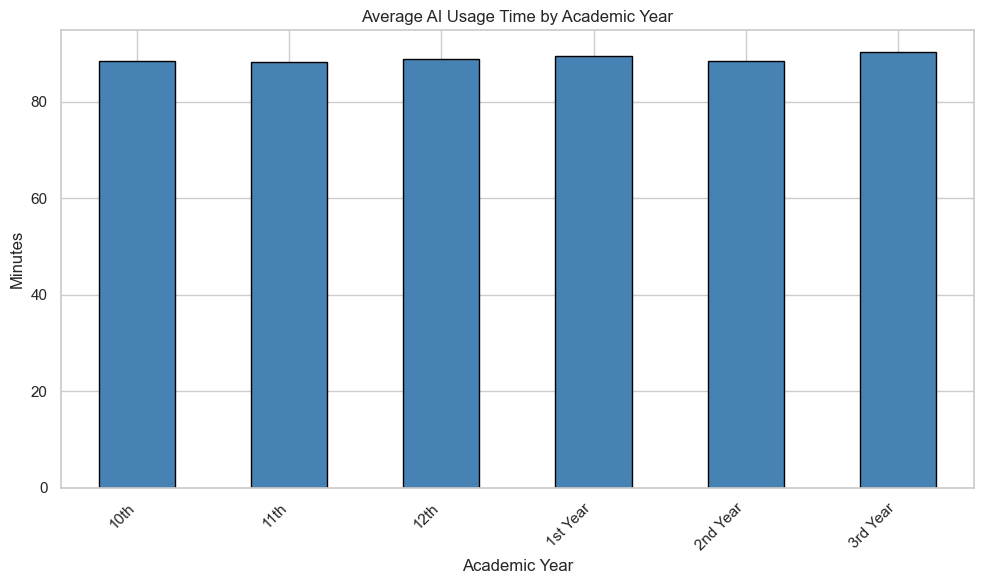

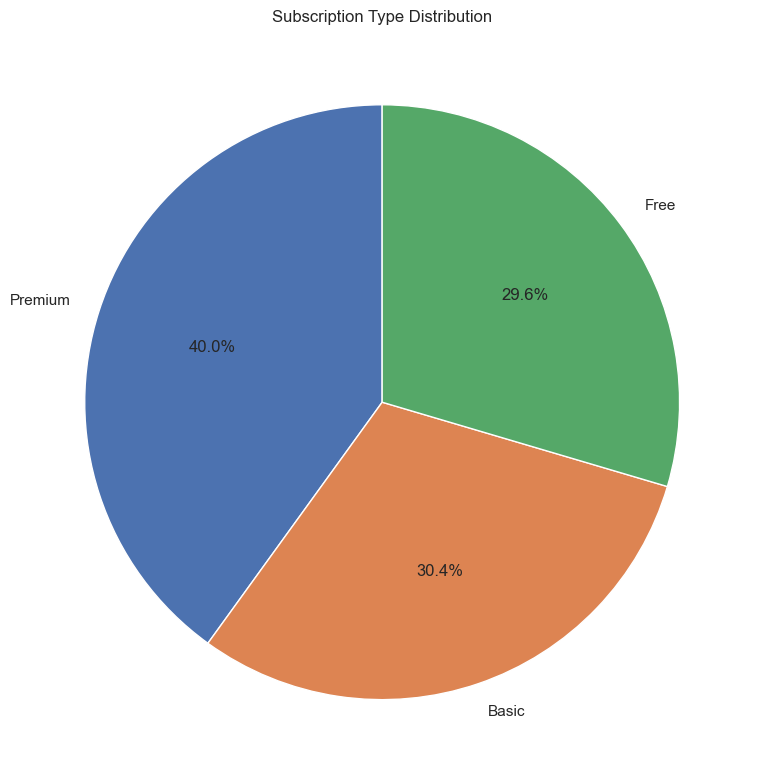

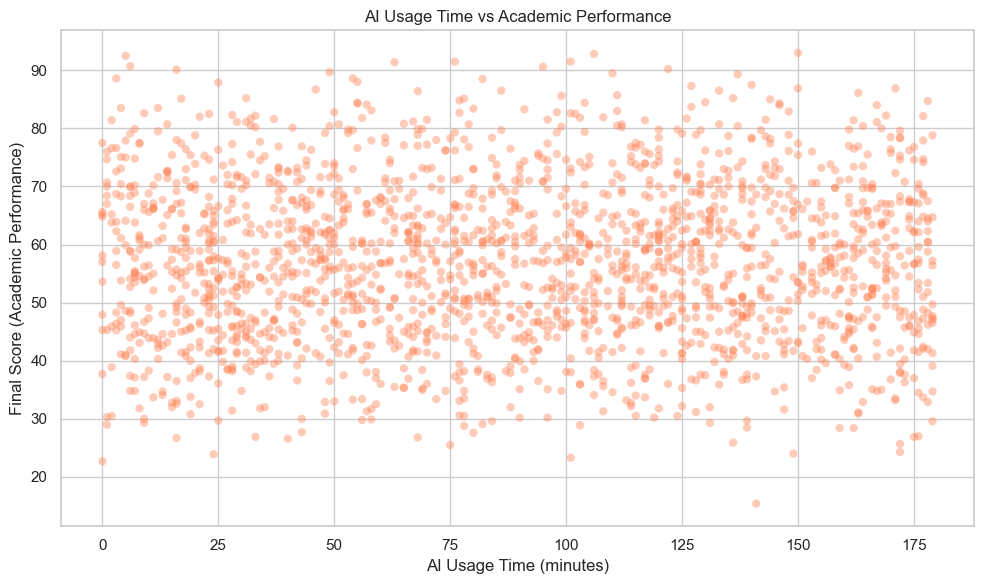

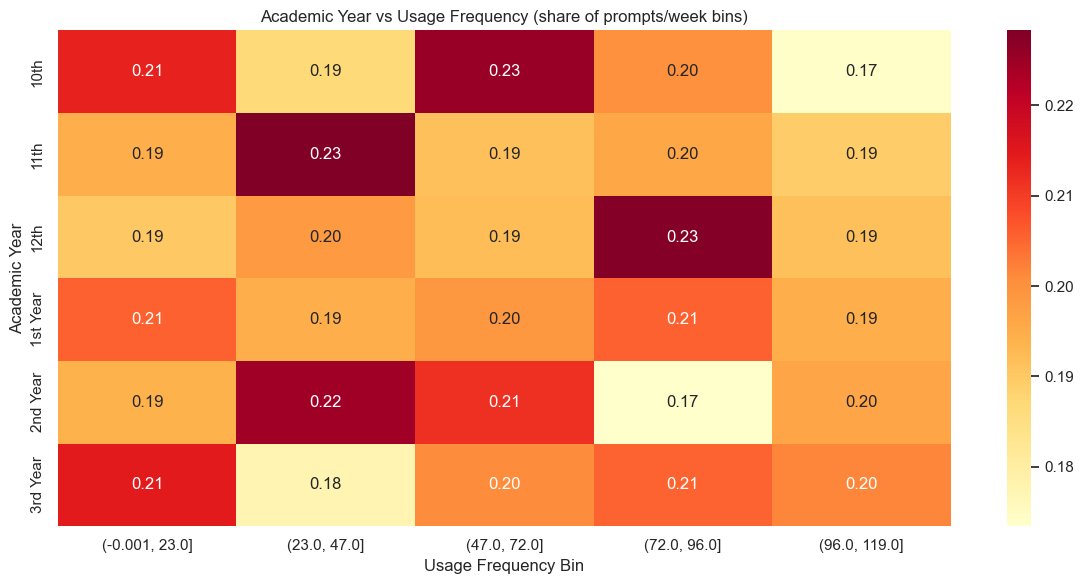

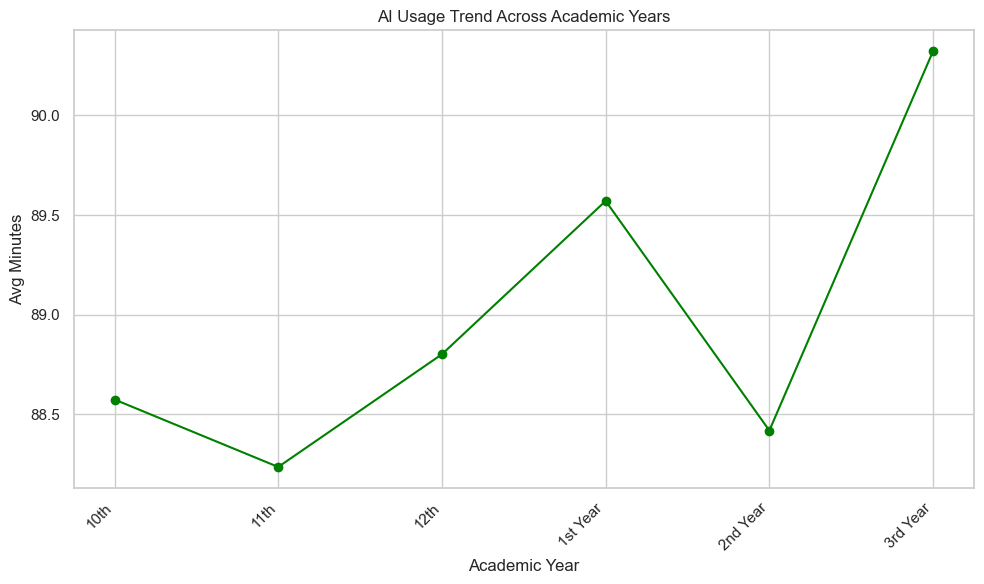

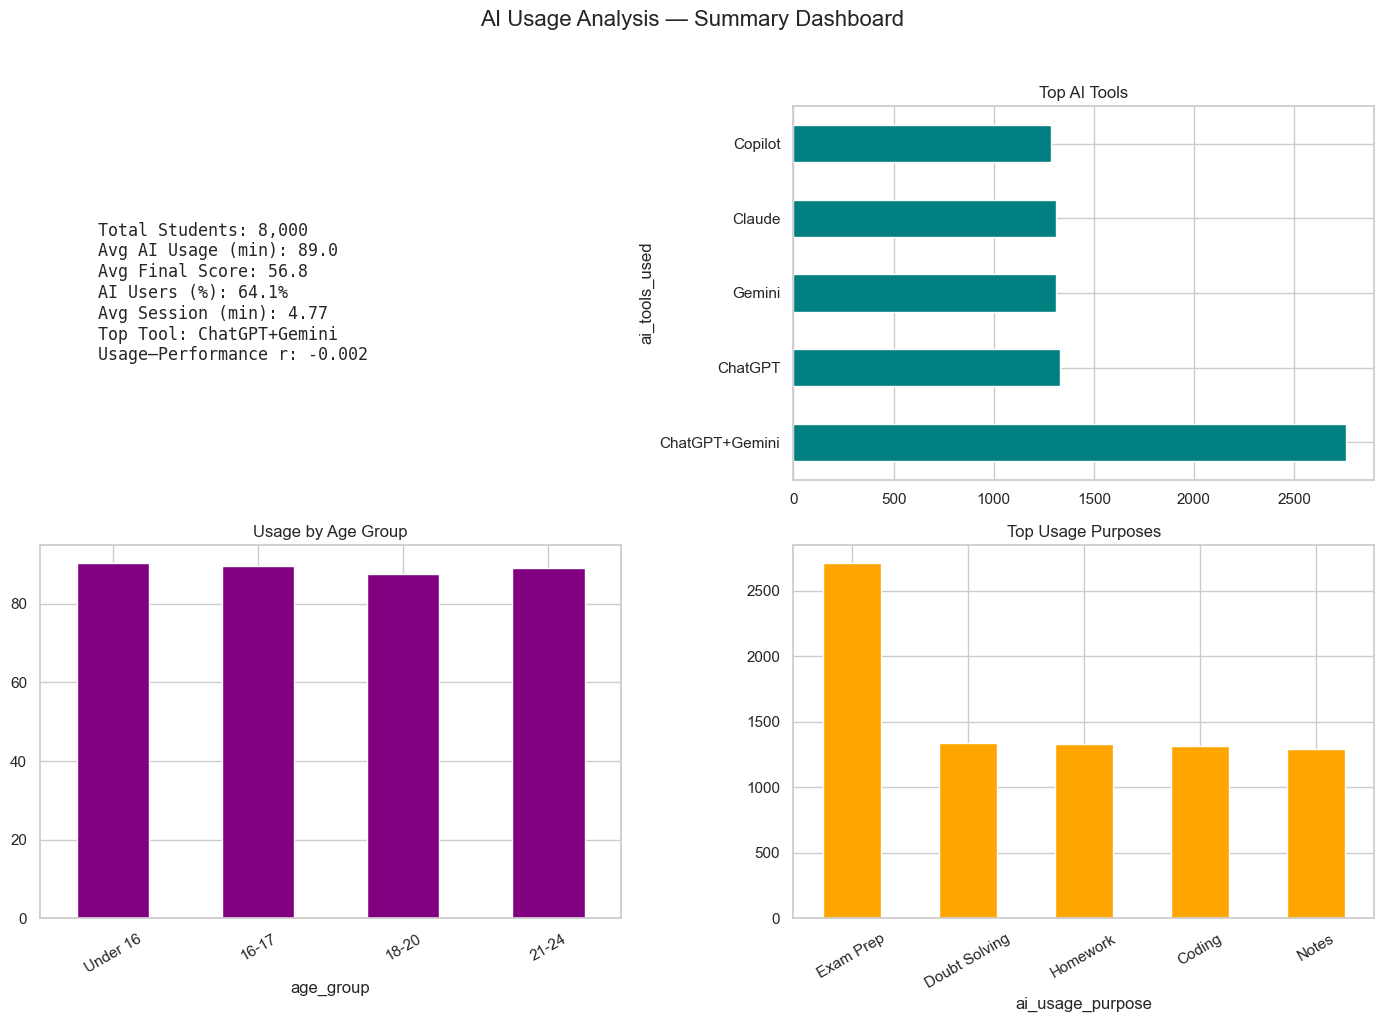

Charts saved to /Users/nilufar/Desktop/AI Usage /ai-usage-analysis/output/


In [6]:
generate_visualizations(df, results)


### 01 — Average AI usage by academic year

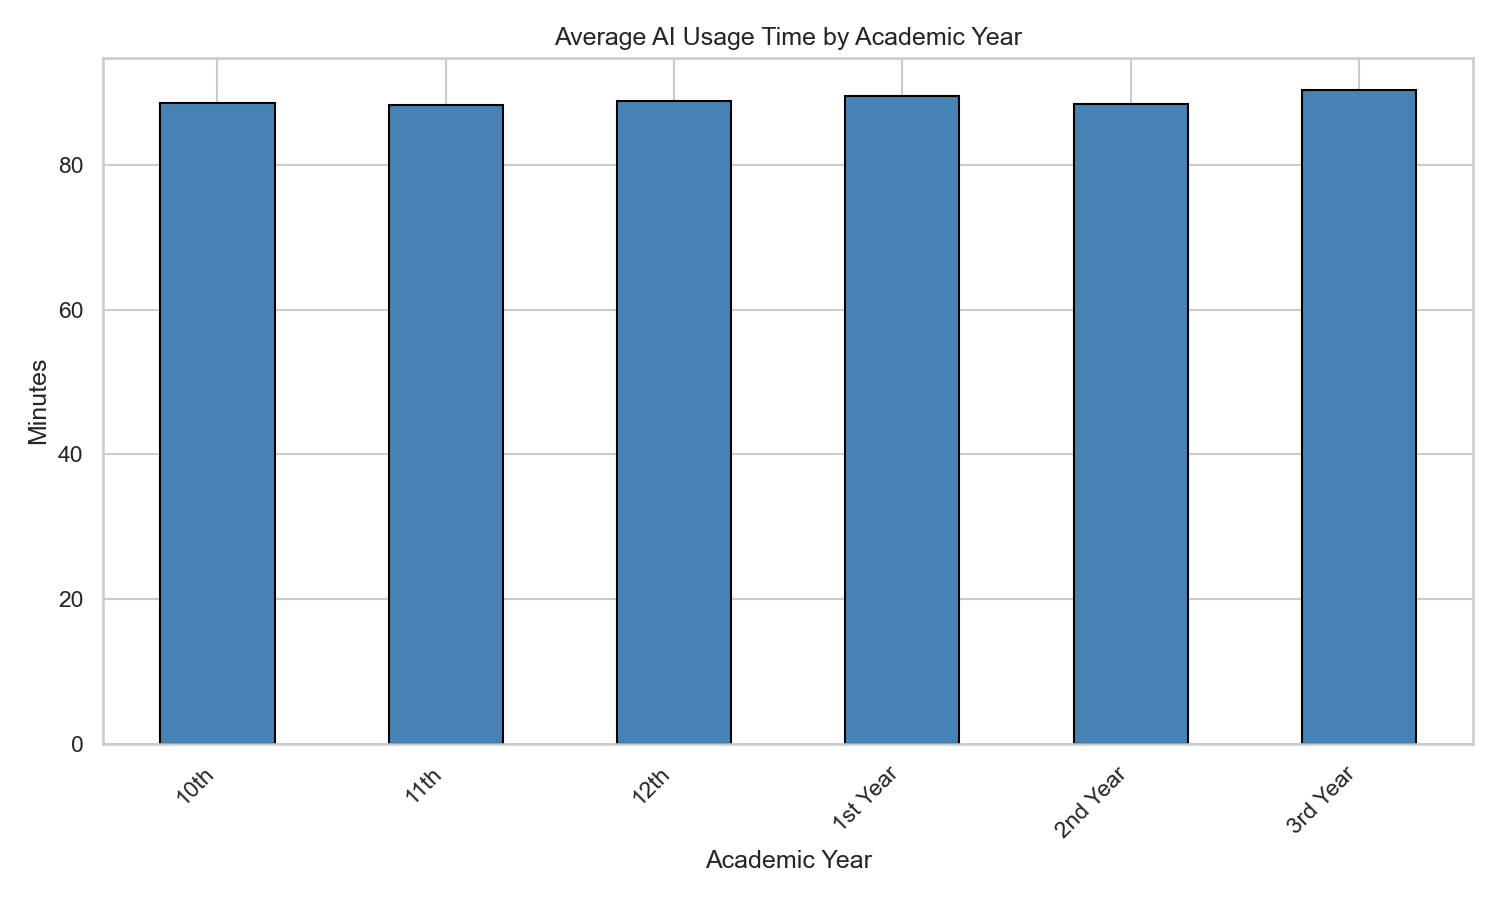

### 02 — Subscription distribution

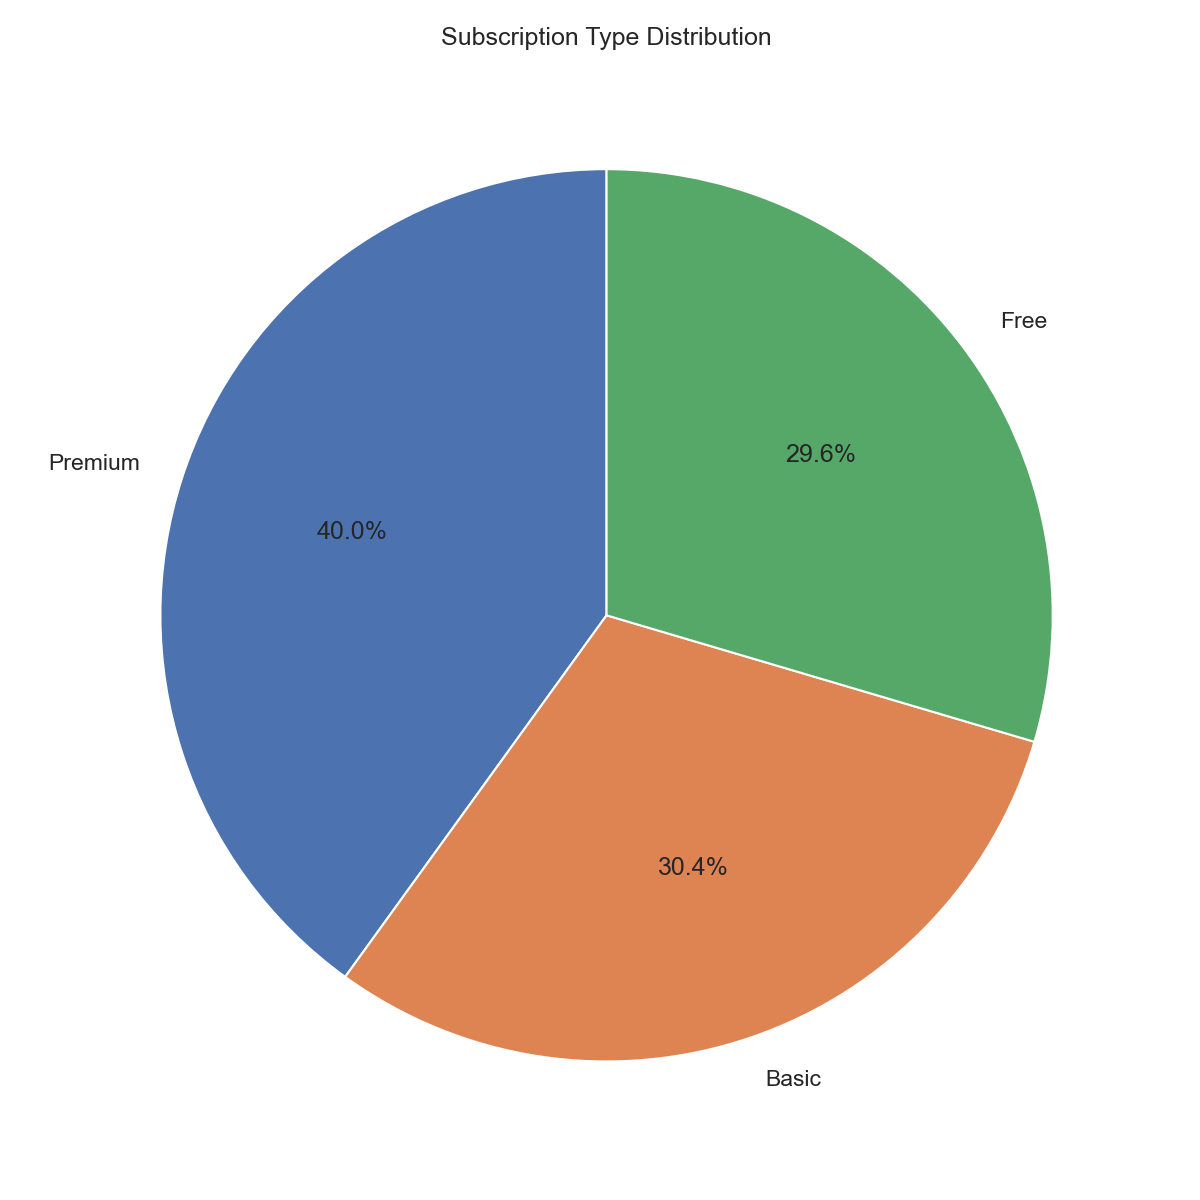

### 03 — AI usage vs academic performance

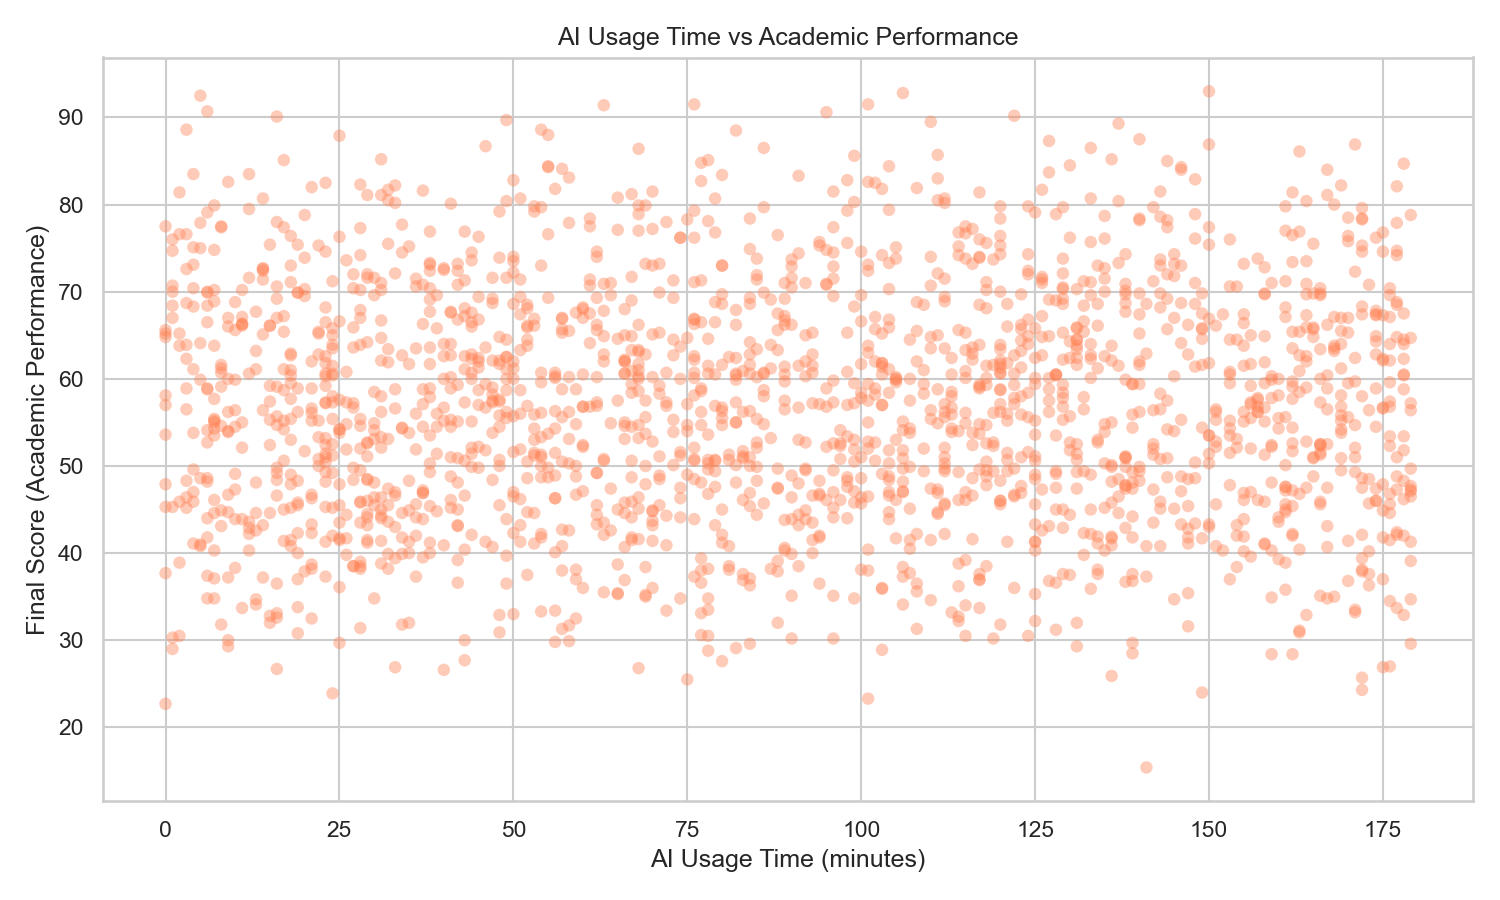

### 04 — Academic year vs usage frequency

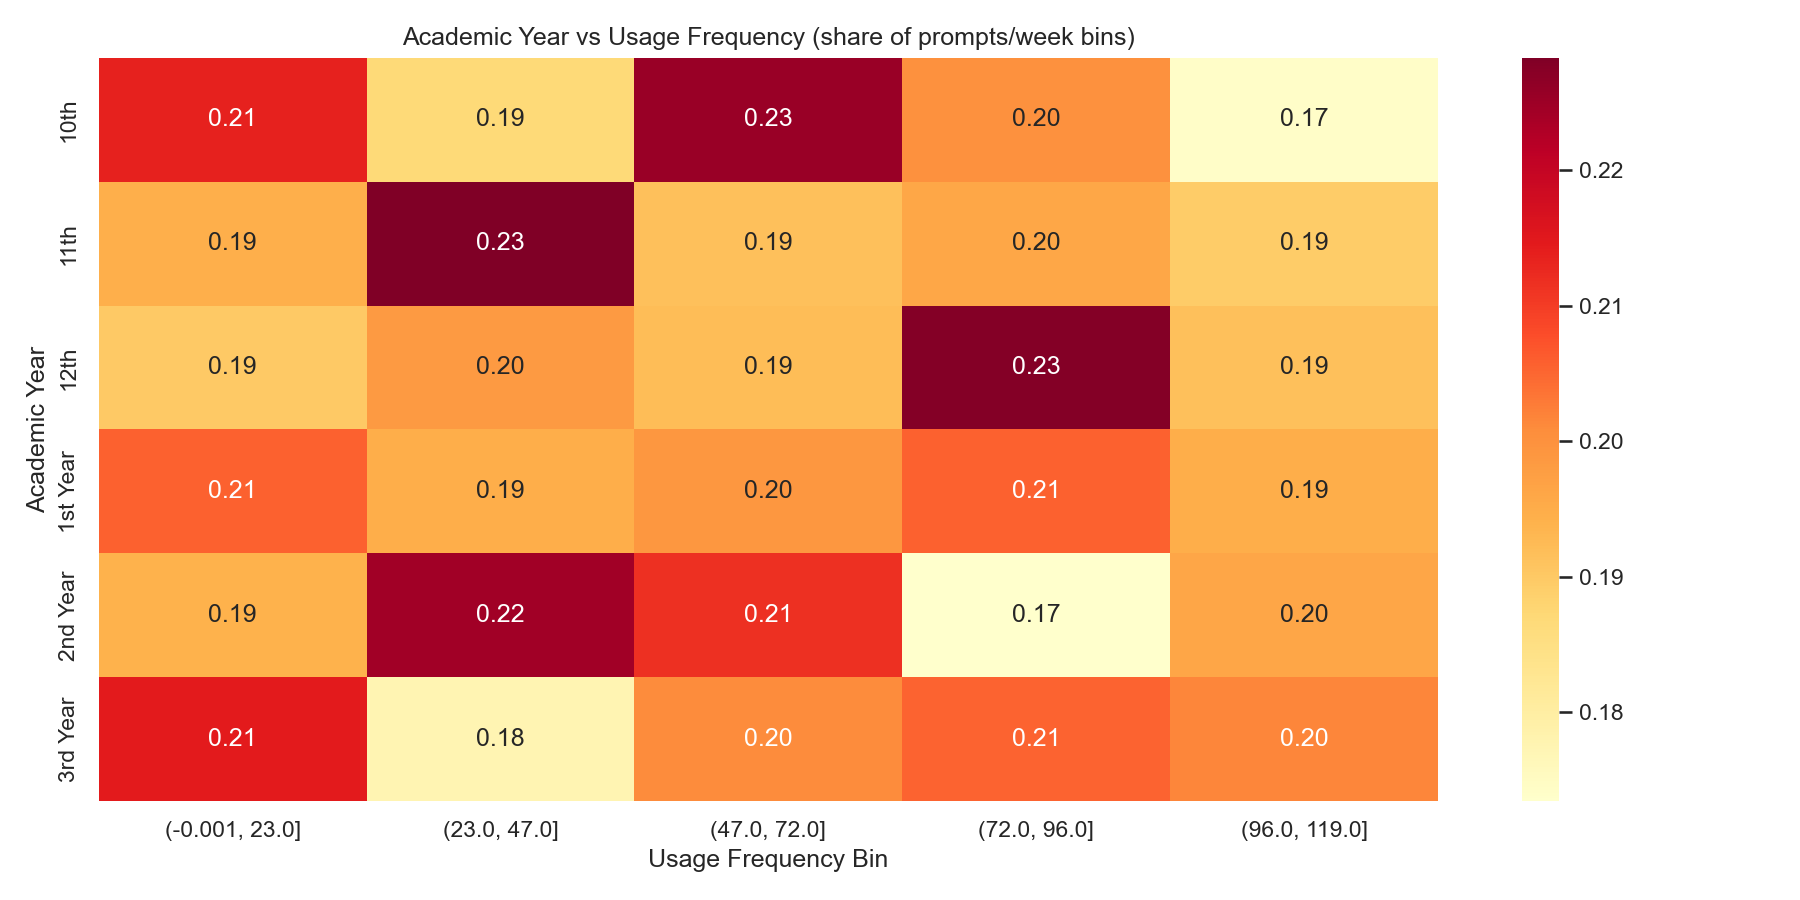

### 05 — AI usage trends

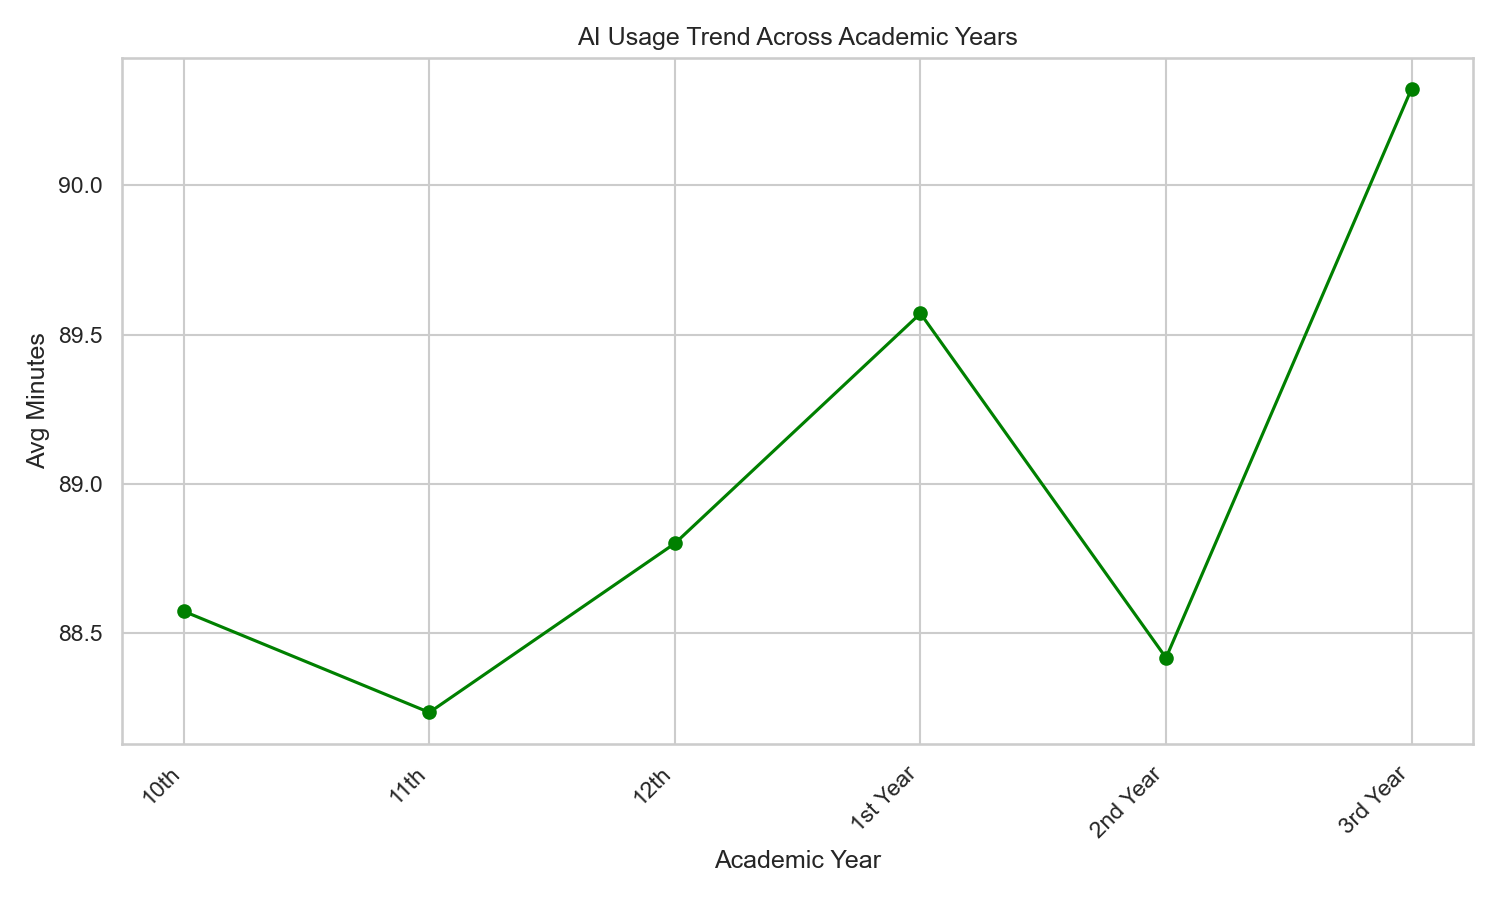

### 06 — Summary dashboard

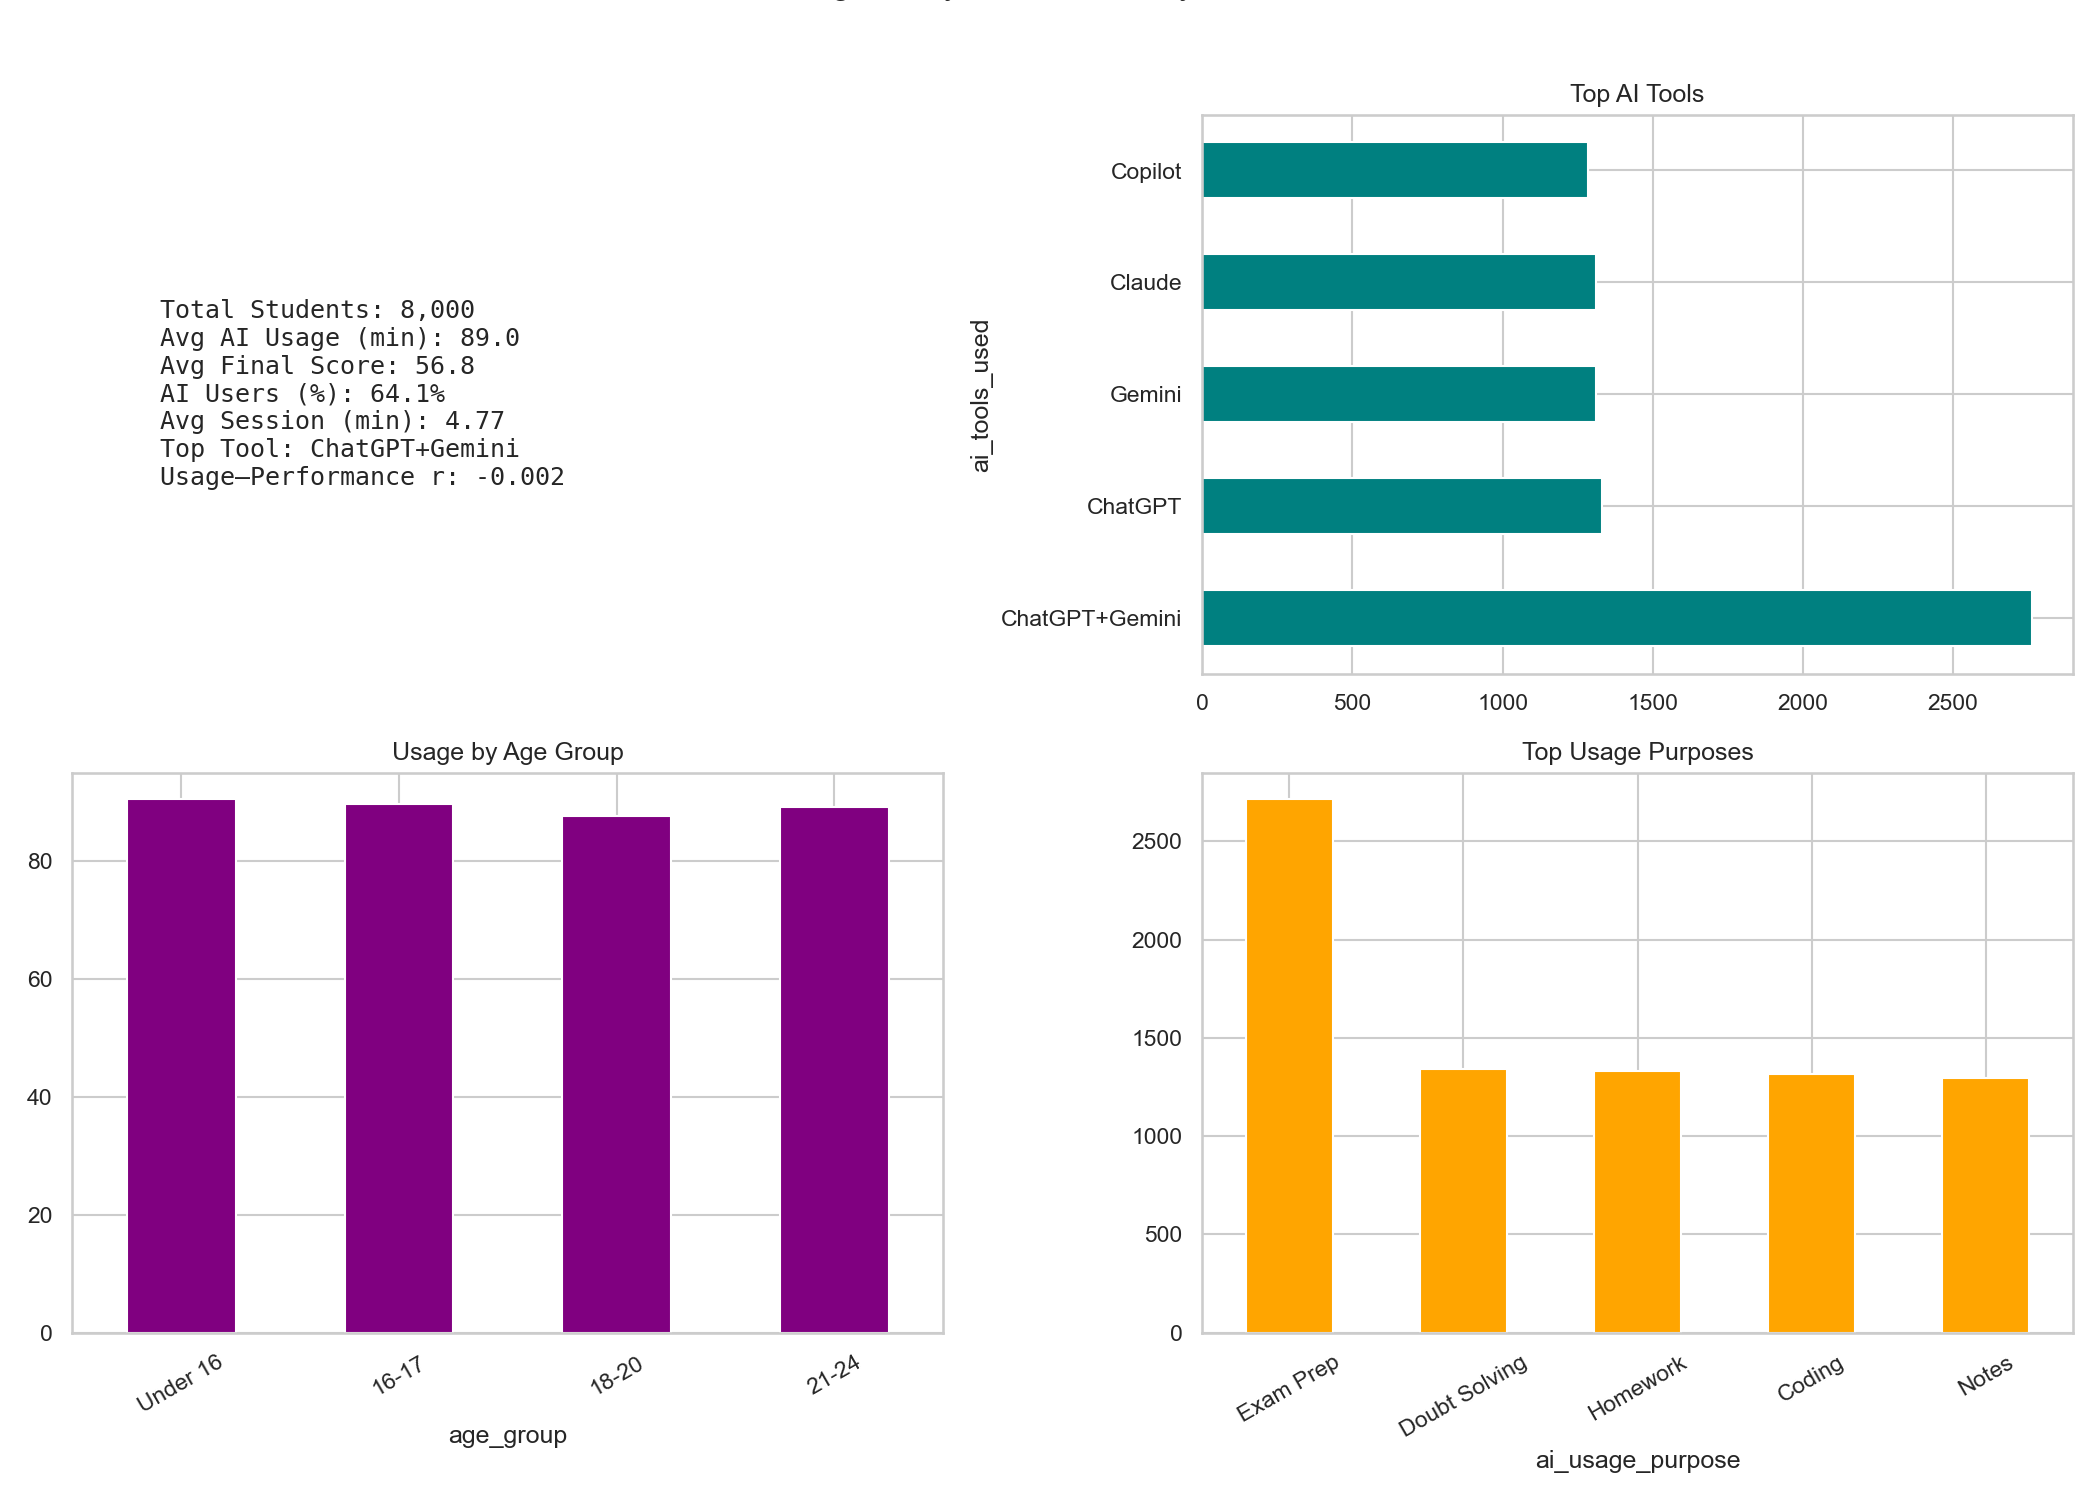

In [7]:
show_png_gallery([
    "01_usage_by_academic_year.png",
    "02_subscription_distribution.png",
    "03_usage_vs_performance.png",
    "04_year_vs_usage_frequency_heatmap.png",
    "05_usage_trends.png",
    "06_summary_dashboard.png",
])


## Automation logic

Rules applied to each student (`Alert_Status`):

| Condition | Alert |
|-----------|--------|
| AI usage > 120 min | High AI Usage |
| Final score < 50 | Academic Support Needed |
| Missed deadlines > 3 | Reminder |
| 1st Year and usage < 40 min | Tutorial Suggestion |

Multiple alerts are combined with `; `. No match → `No Alert`.


In [8]:
df = apply_automation_rules(df)



5. AUTOMATION RULES

Alert counts (including combined statuses):
Alert_Status
Reminder                   3835
High AI Usage              2592
Academic Support Needed    2517
No Alert                   1787
Tutorial Suggestion         318
Name: count, dtype: int64



6. AUTOMATION VISUALIZATIONS


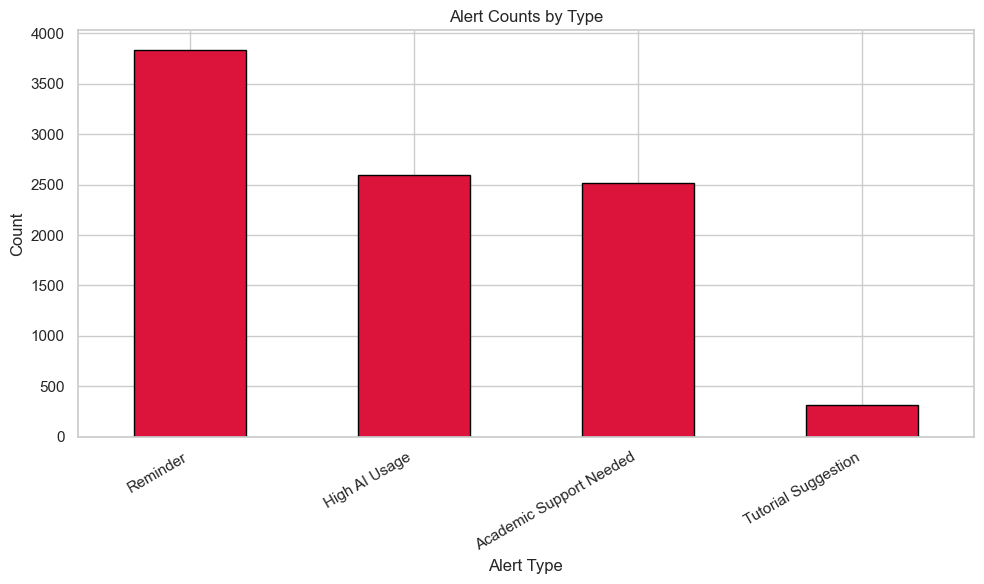

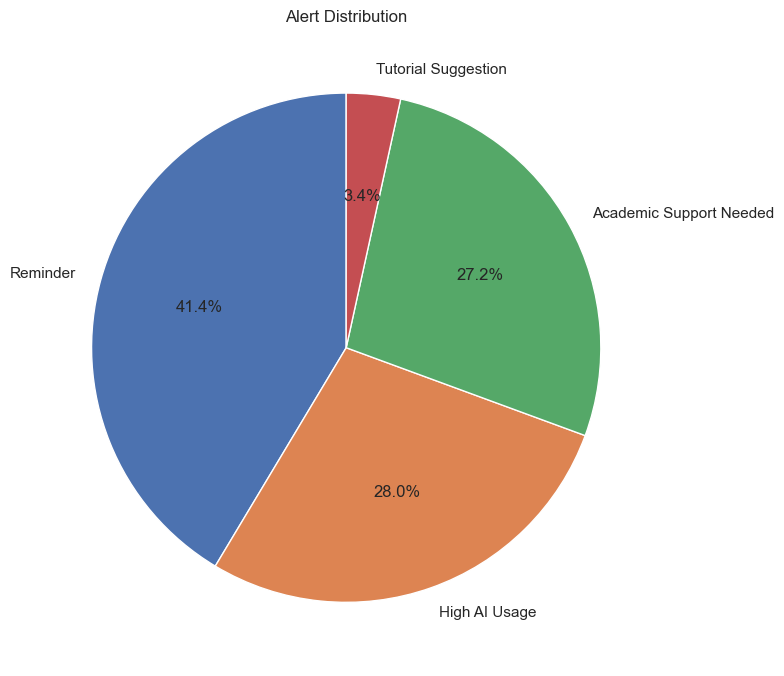

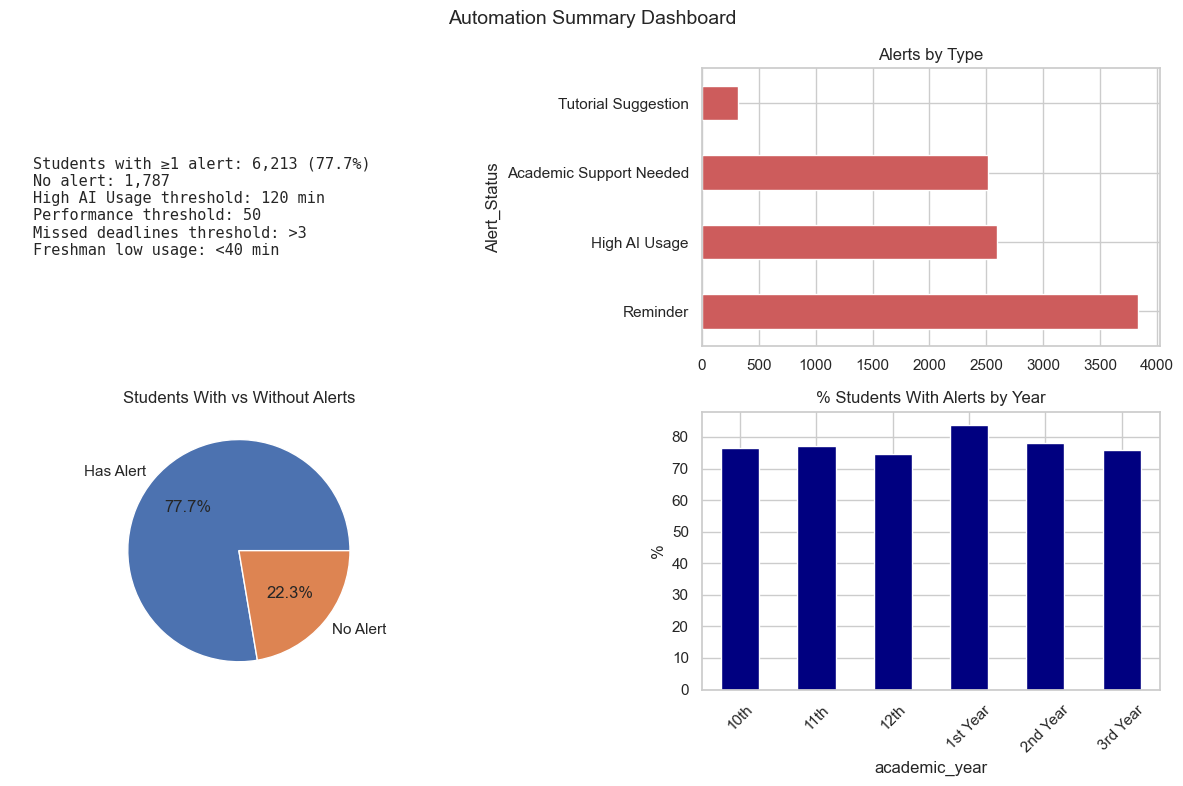

Automation charts saved to /Users/nilufar/Desktop/AI Usage /ai-usage-analysis/output/


In [9]:
visualize_automation(df)


### 07 — Alert counts

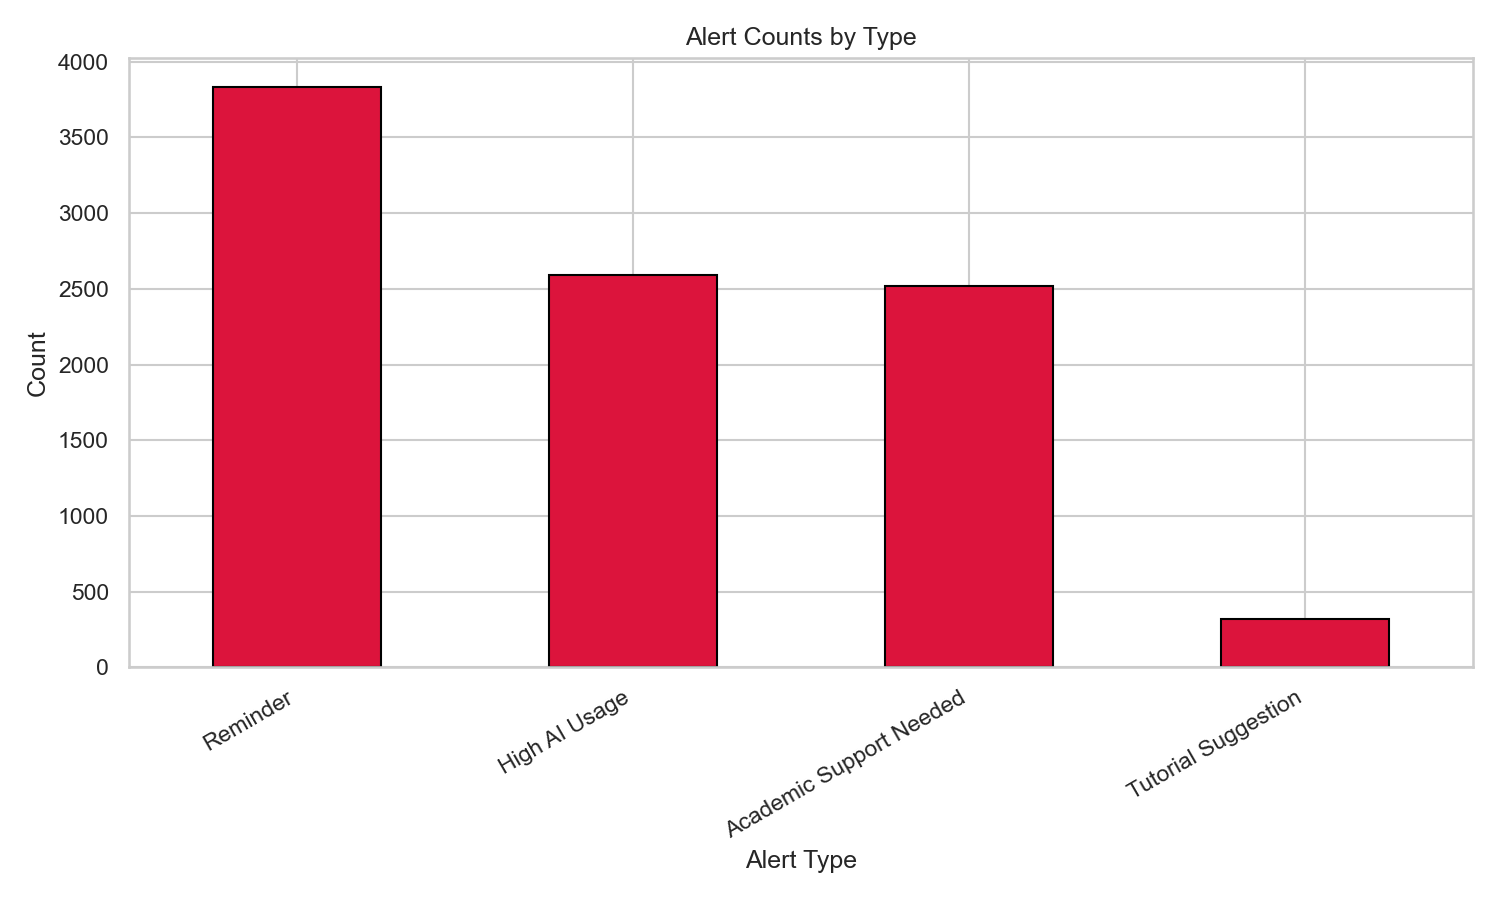

### 08 — Alert distribution

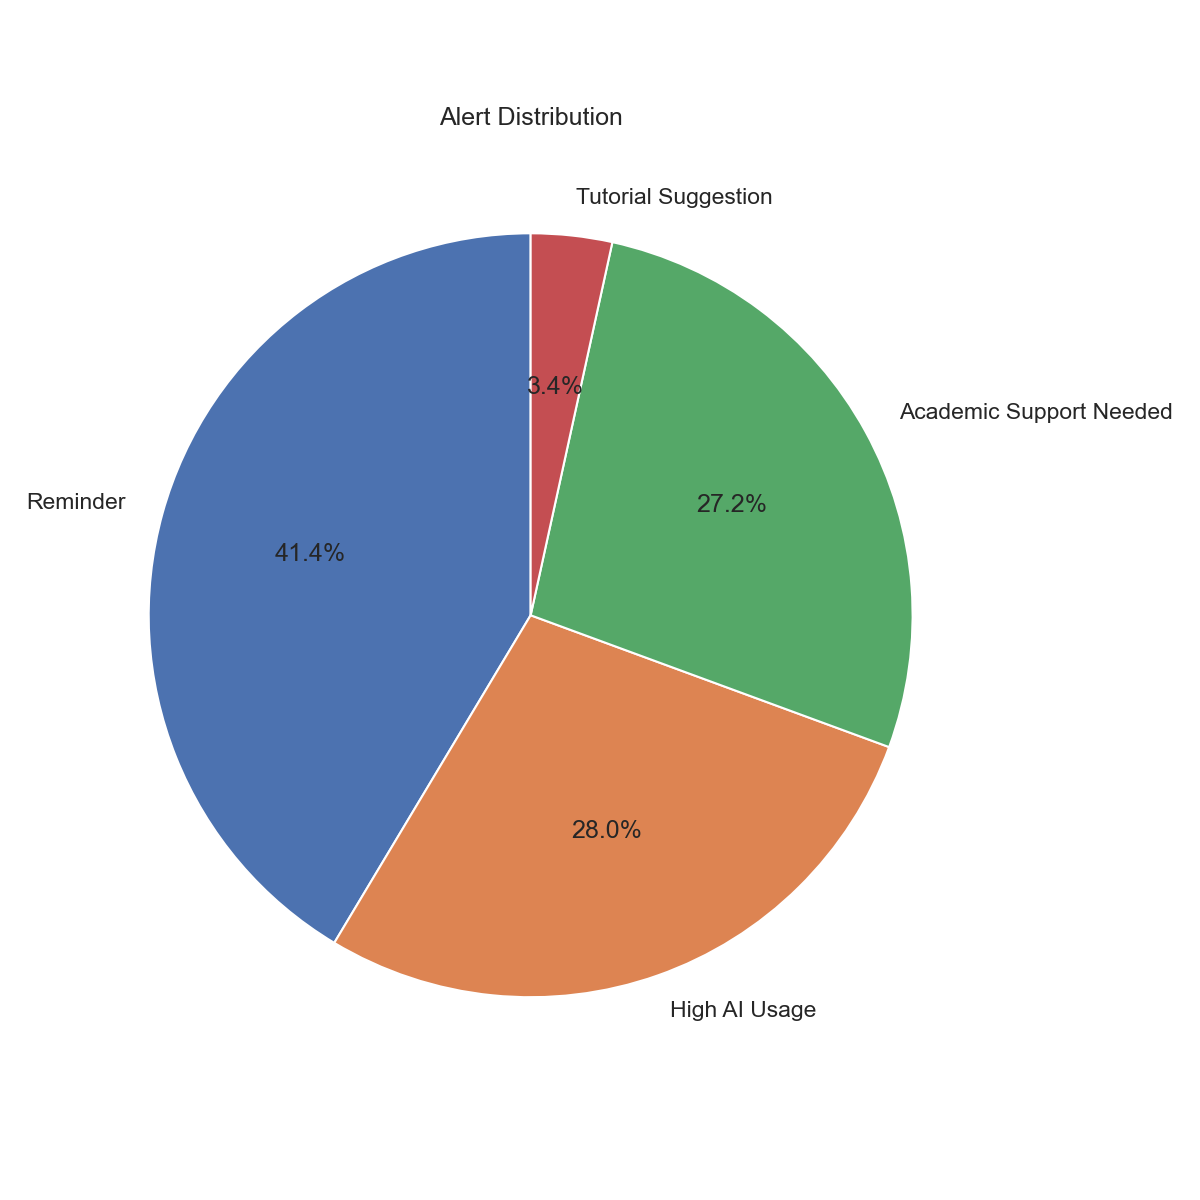

### 09 — Automation dashboard

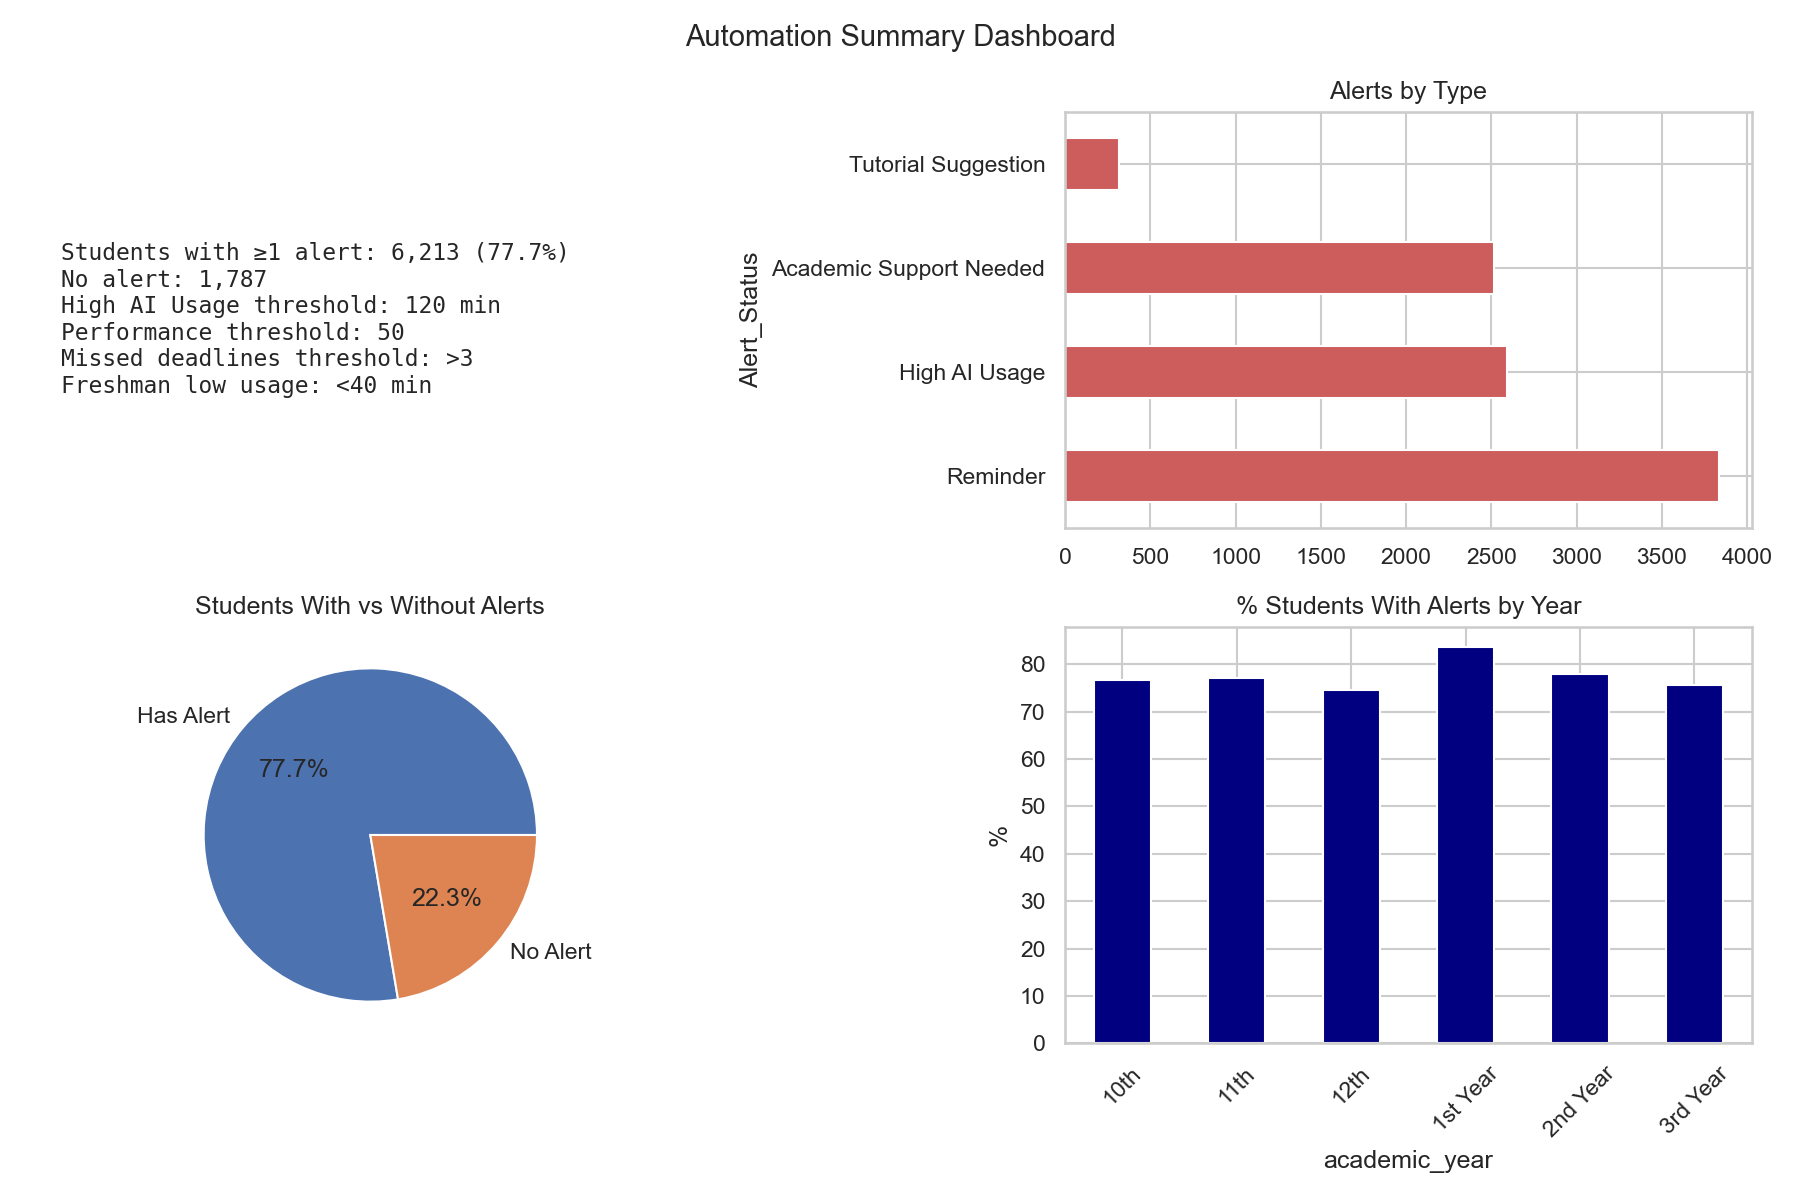

In [10]:
show_png_gallery([
    "07_alert_counts.png",
    "08_alert_distribution.png",
    "09_automation_dashboard.png",
])


## Results

Outputs:

- `output/processed_students_with_alerts.csv` — full dataset with alerts
- `output/*.png` — chart images (01–09)
- `output/analysis_report.html` — standalone HTML summary


Saved: /Users/nilufar/Desktop/AI Usage /ai-usage-analysis/output/processed_students_with_alerts.csv


### Sample rows with Alert_Status

,student_id,grade_level,ai_usage_time_minutes,final_score,Alert_Status
0,1,1st Year,170,36.8,High AI Usage; Academic Support Needed
1,2,12th,123,65.5,High AI Usage
2,3,3rd Year,35,66.3,Reminder
3,4,12th,45,69.5,Reminder
4,5,3rd Year,21,49.7,Academic Support Needed; Reminder
5,6,1st Year,34,77.9,Tutorial Suggestion
6,7,1st Year,112,82.2,No Alert
7,8,3rd Year,174,52.7,High AI Usage
8,9,10th,32,81.7,No Alert
9,10,1st Year,140,66.7,High AI Usage; Reminder


### Alert summary

,count
Alert_Status,
Reminder,3835
High AI Usage,2592
Academic Support Needed,2517
No Alert,1787
Tutorial Suggestion,318


### 01 — Average AI usage by academic year

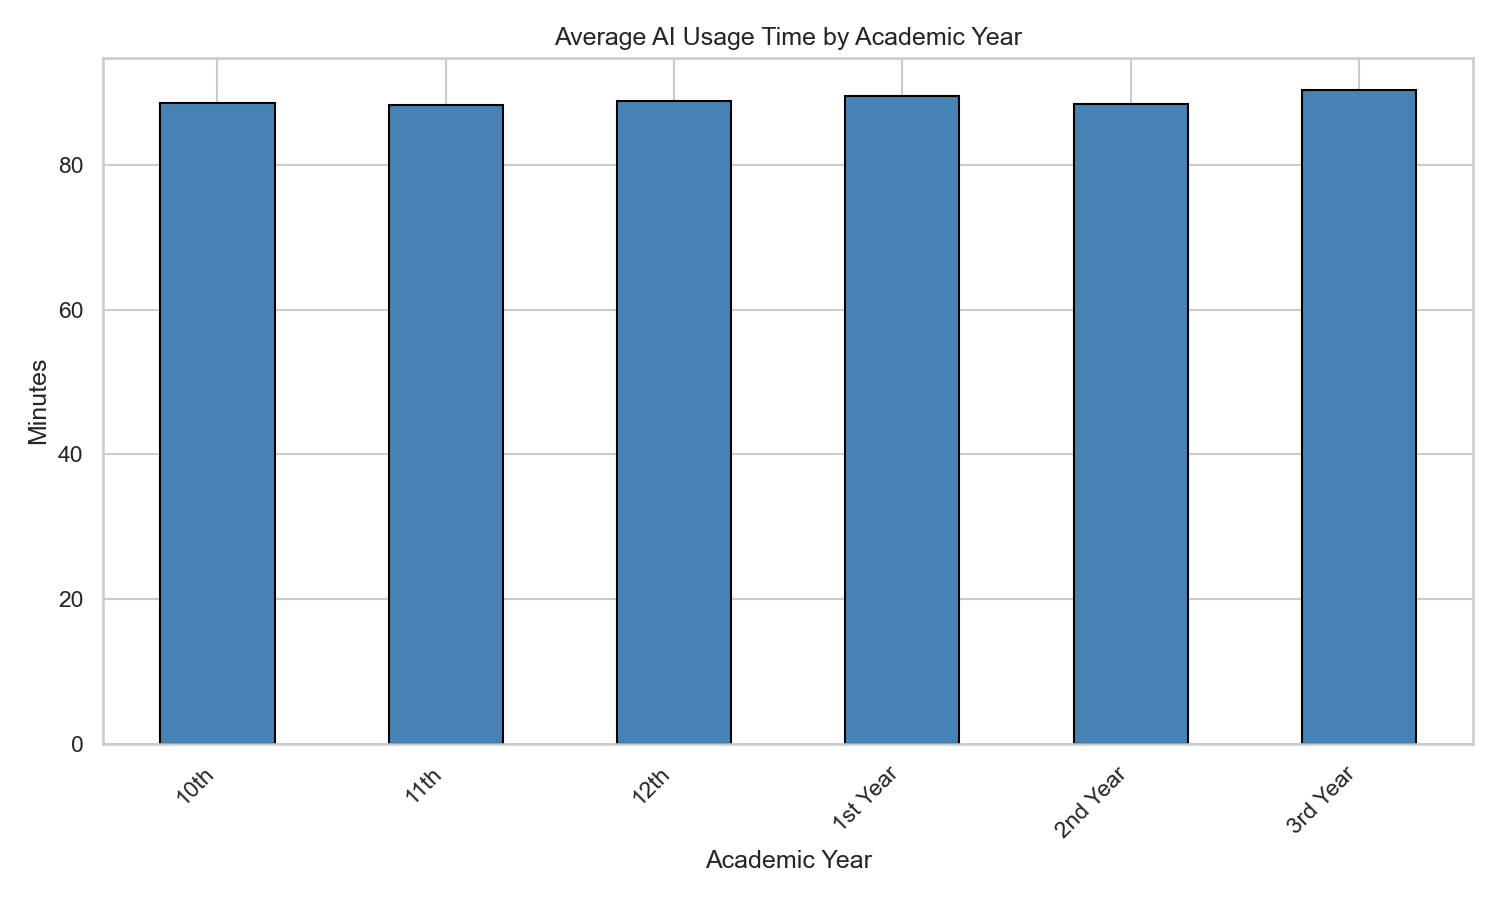

### 02 — Subscription distribution

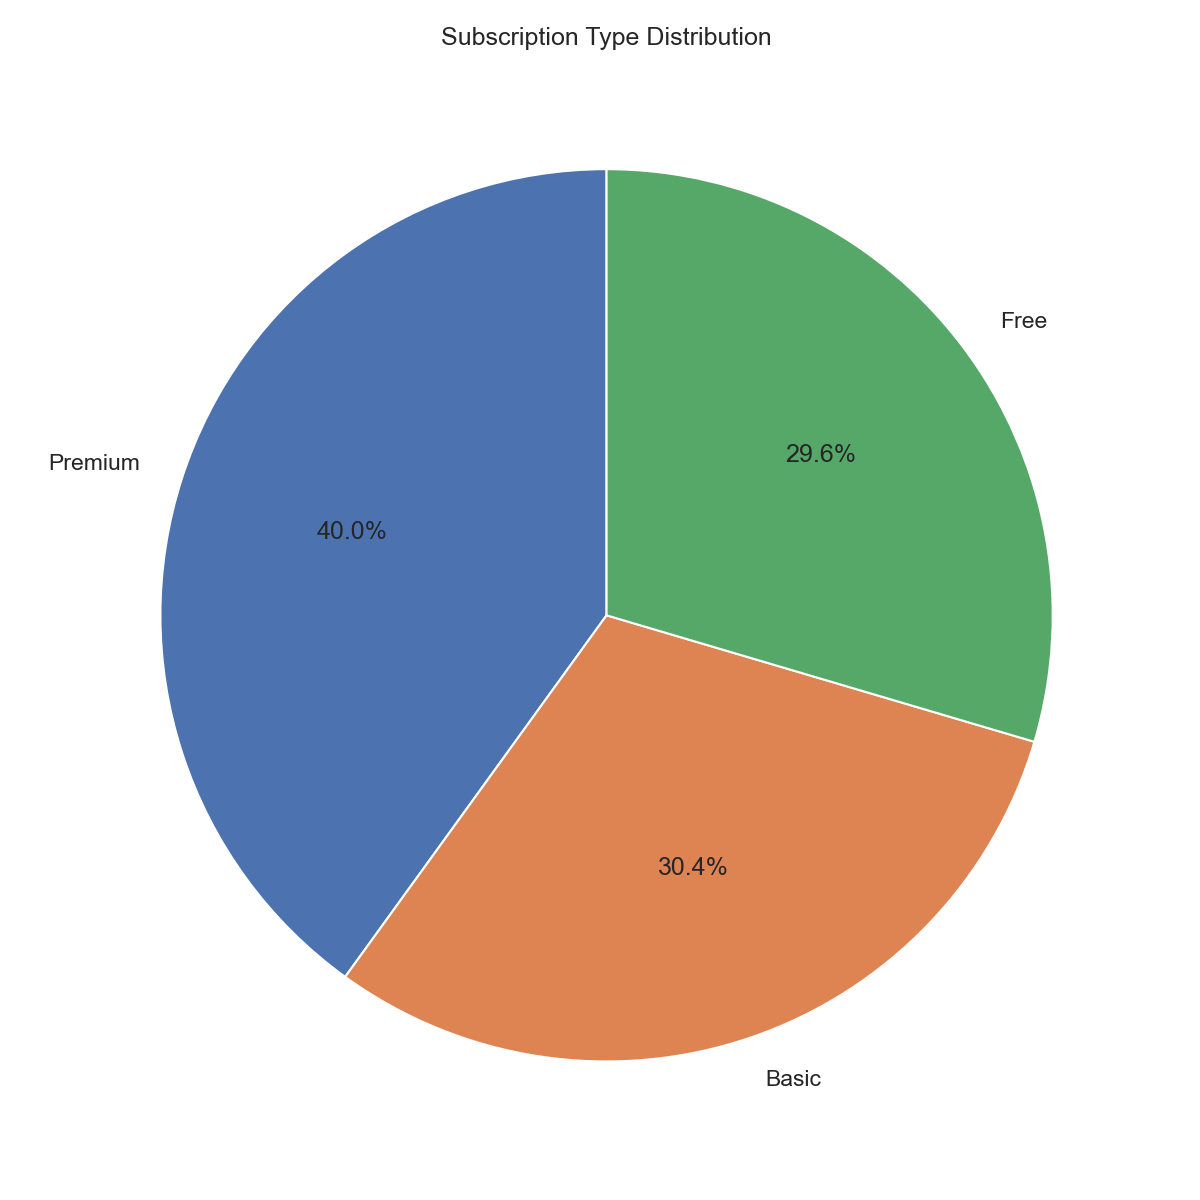

### 03 — AI usage vs academic performance

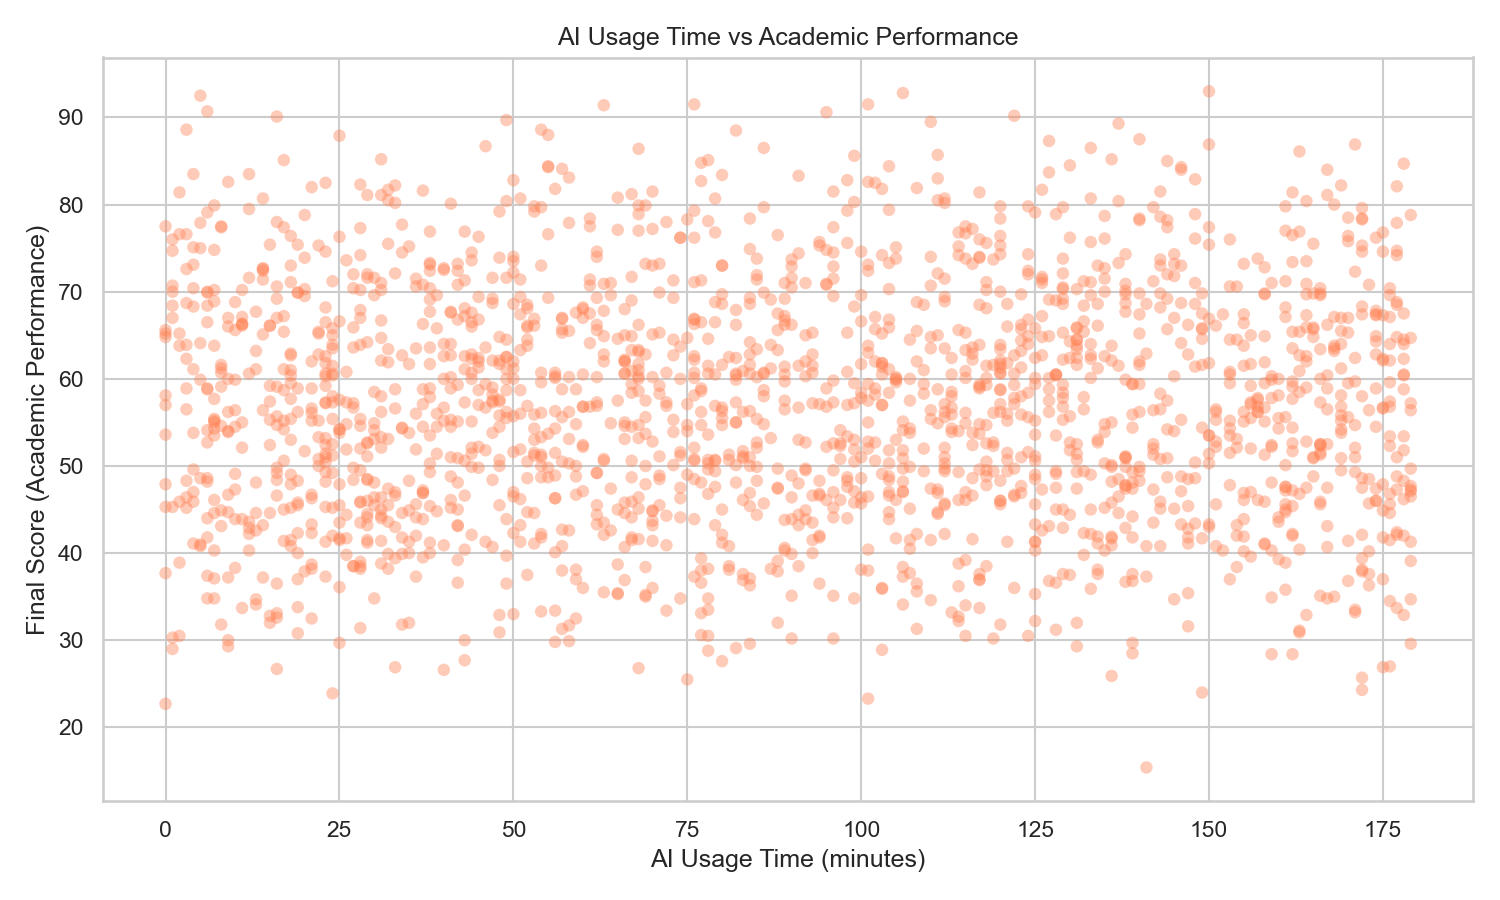

### 04 — Academic year vs usage frequency

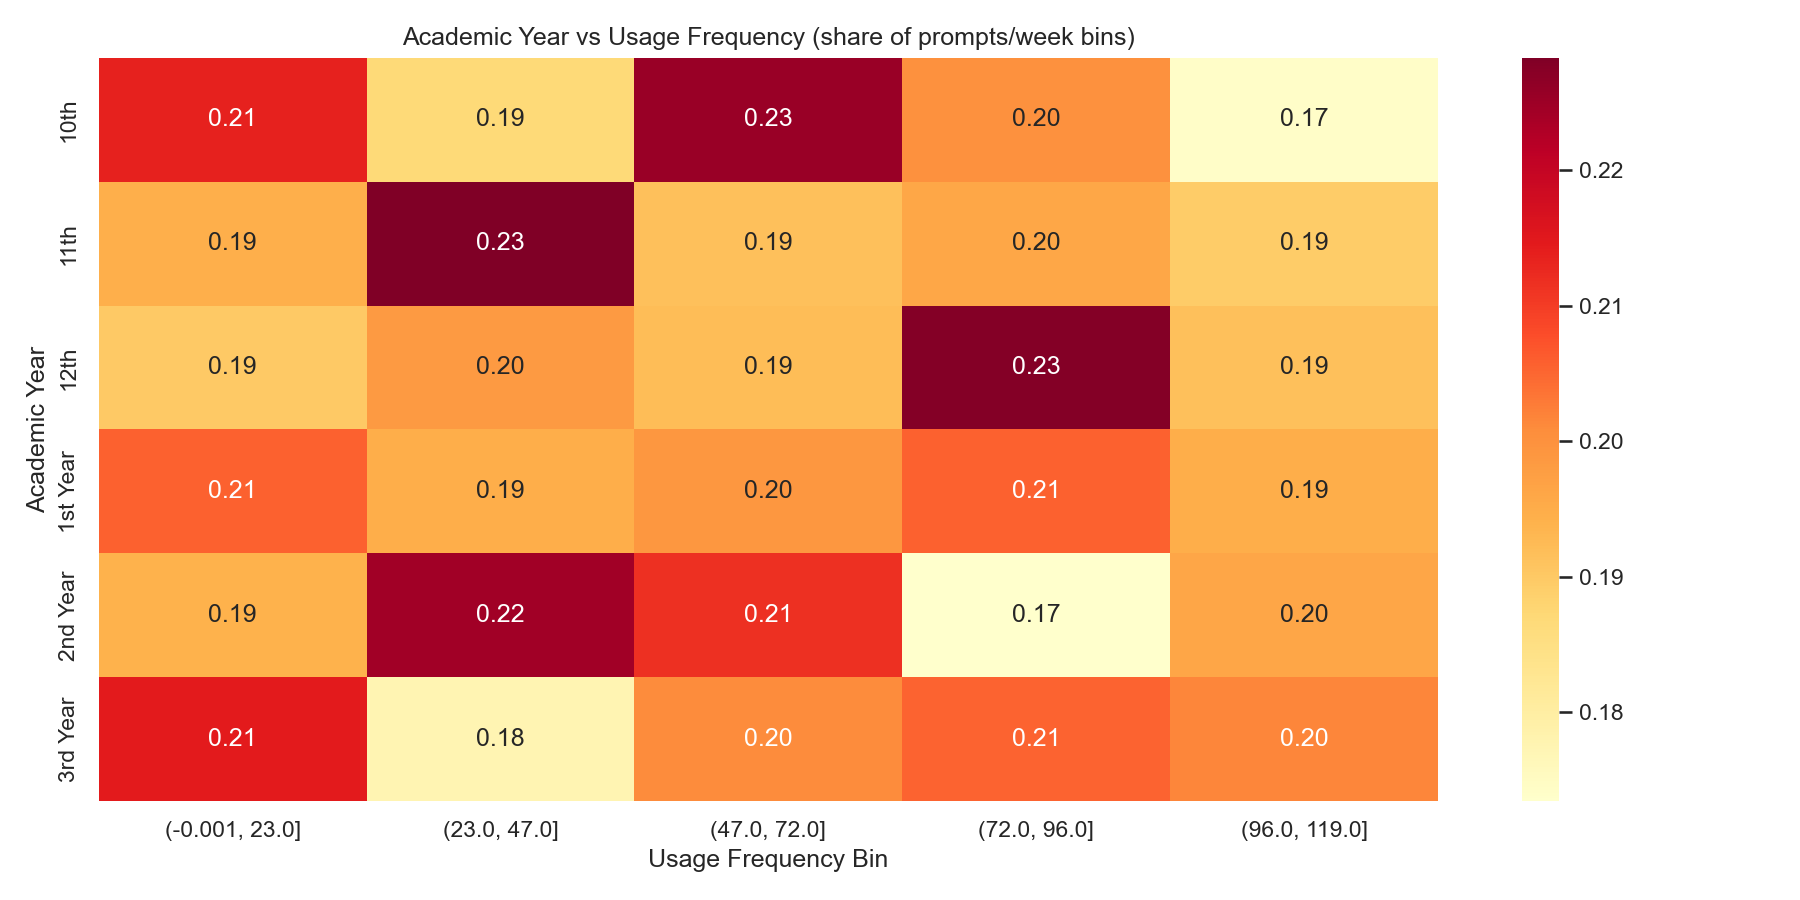

### 05 — AI usage trends

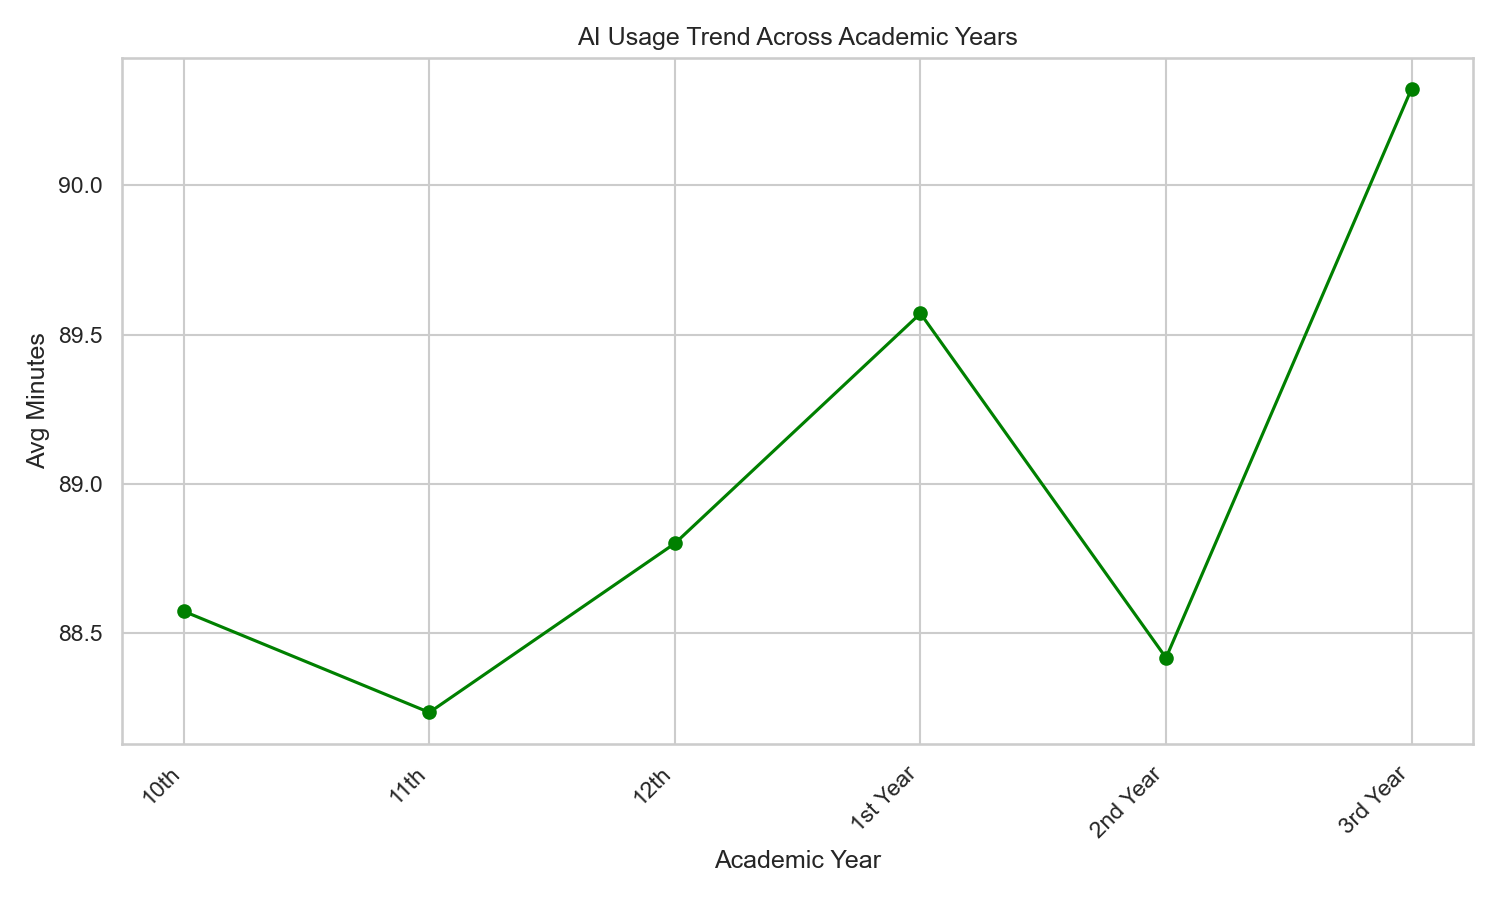

### 06 — Summary dashboard

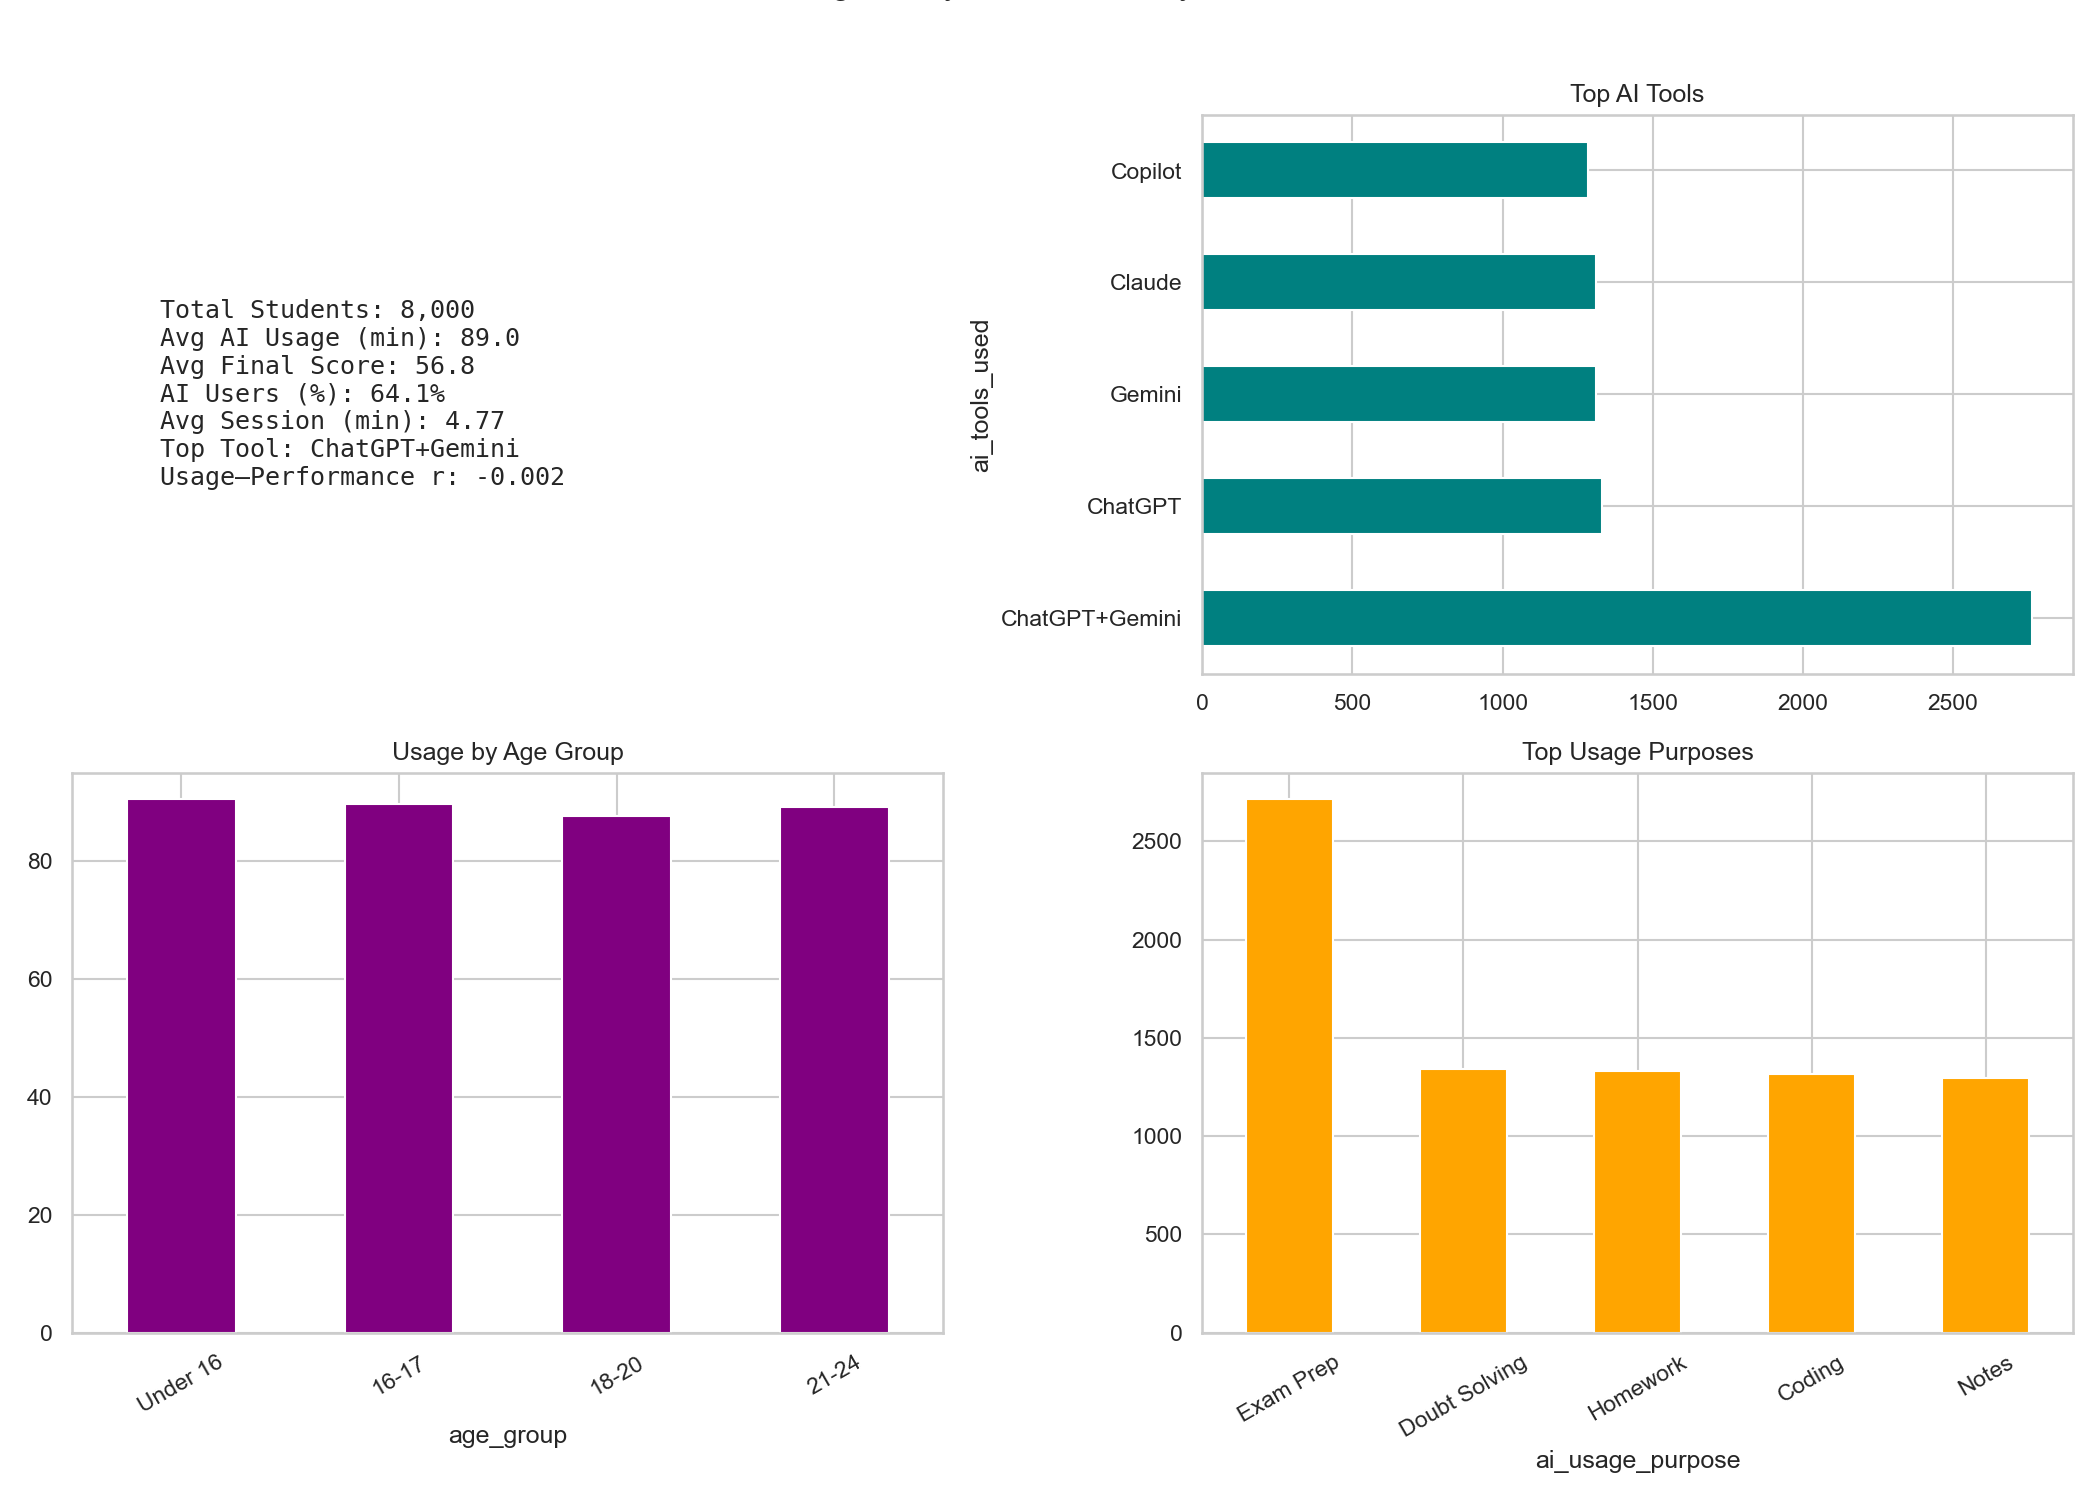

### 07 — Alert counts

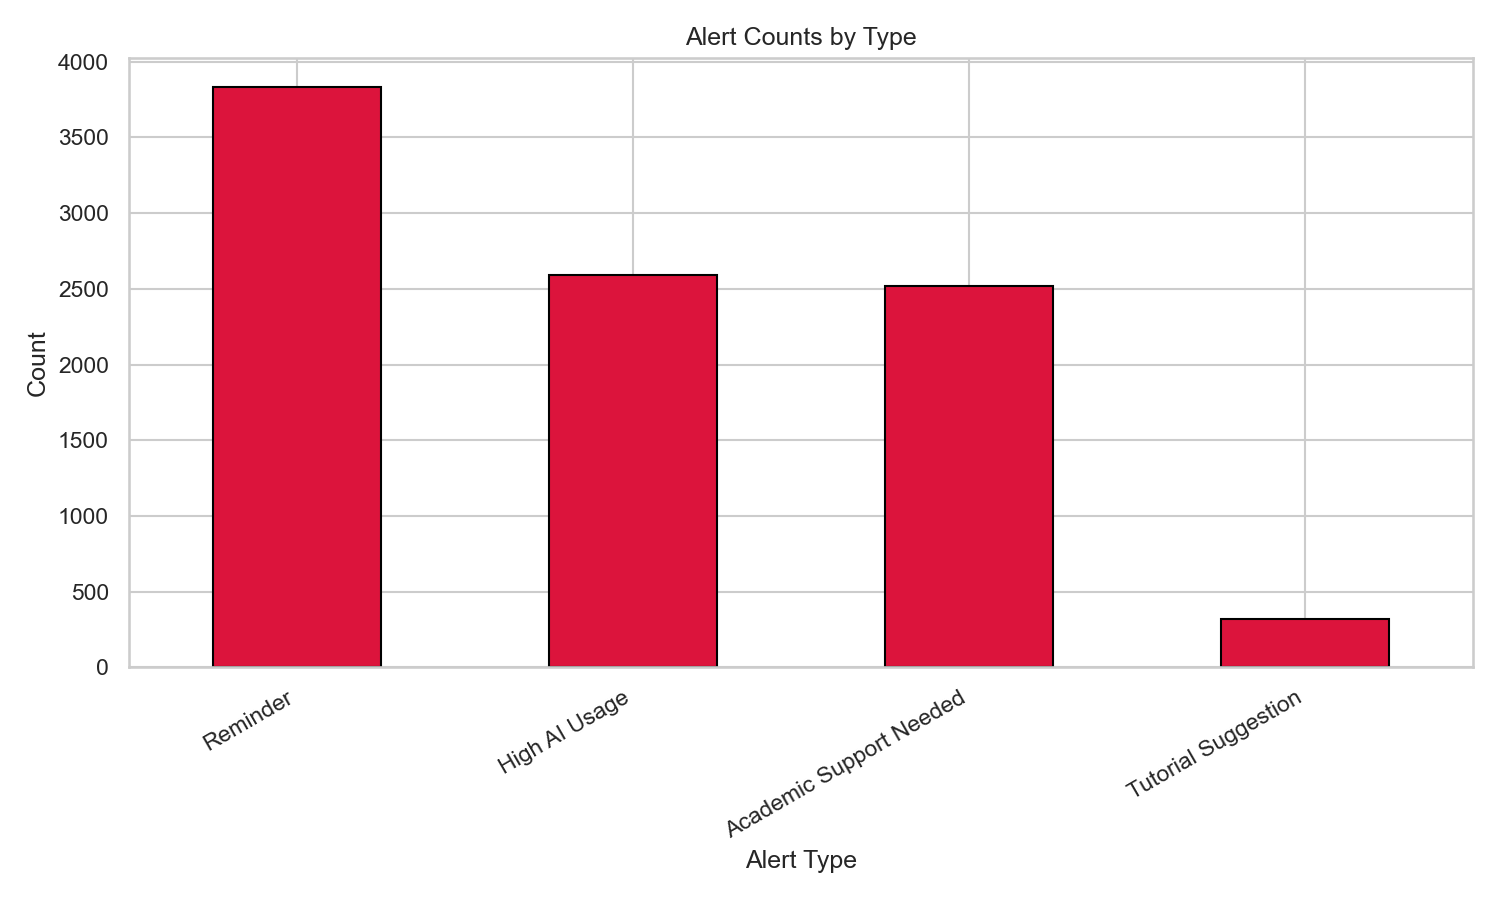

### 08 — Alert distribution

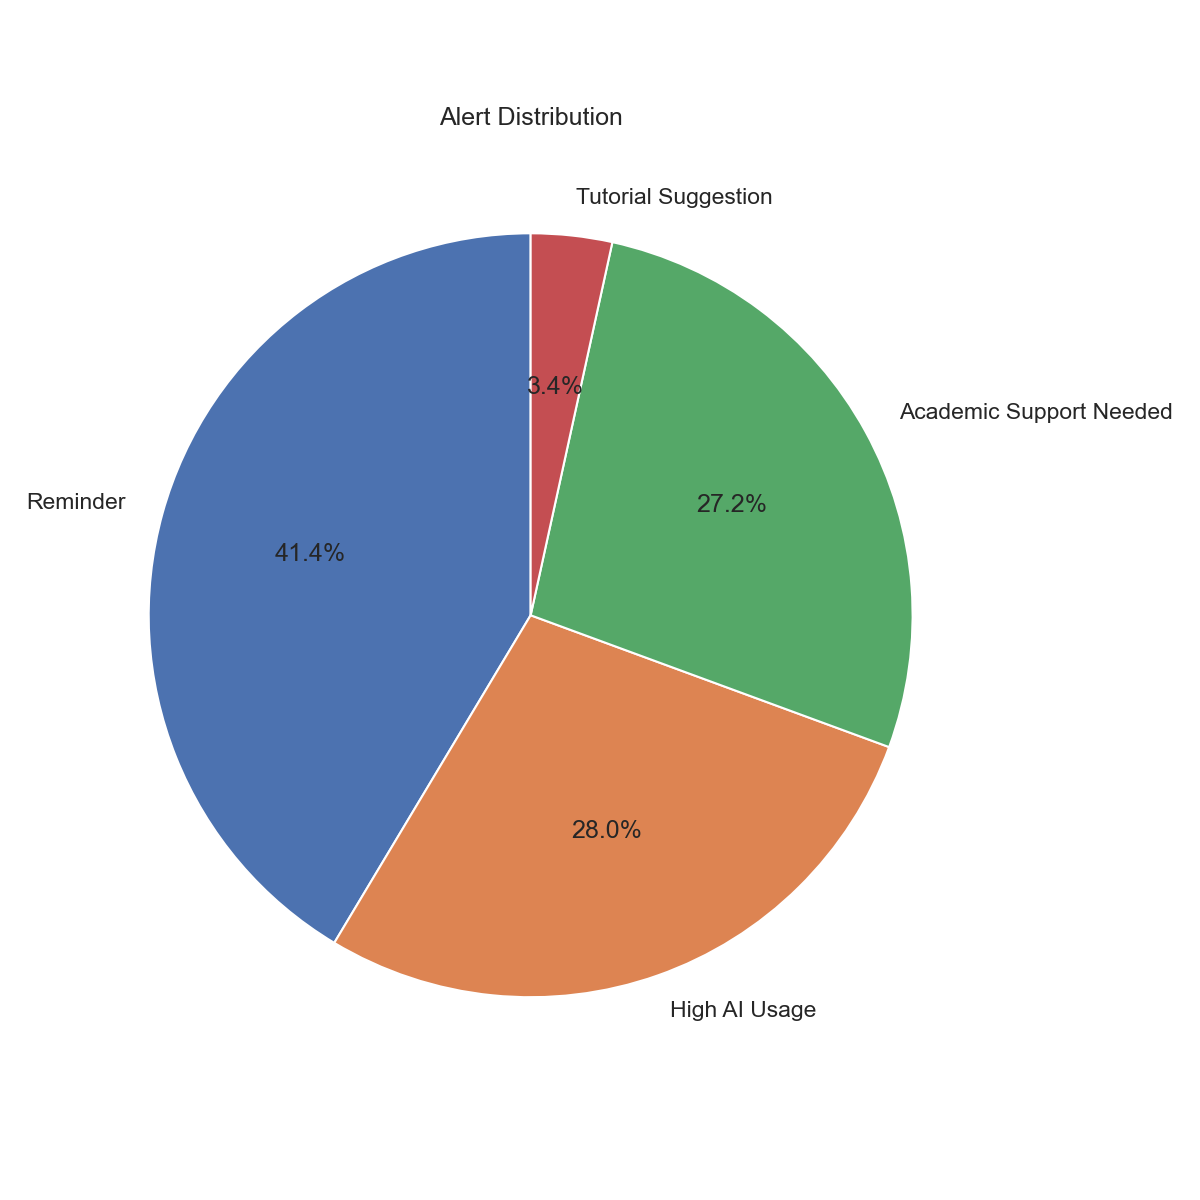

### 09 — Automation dashboard

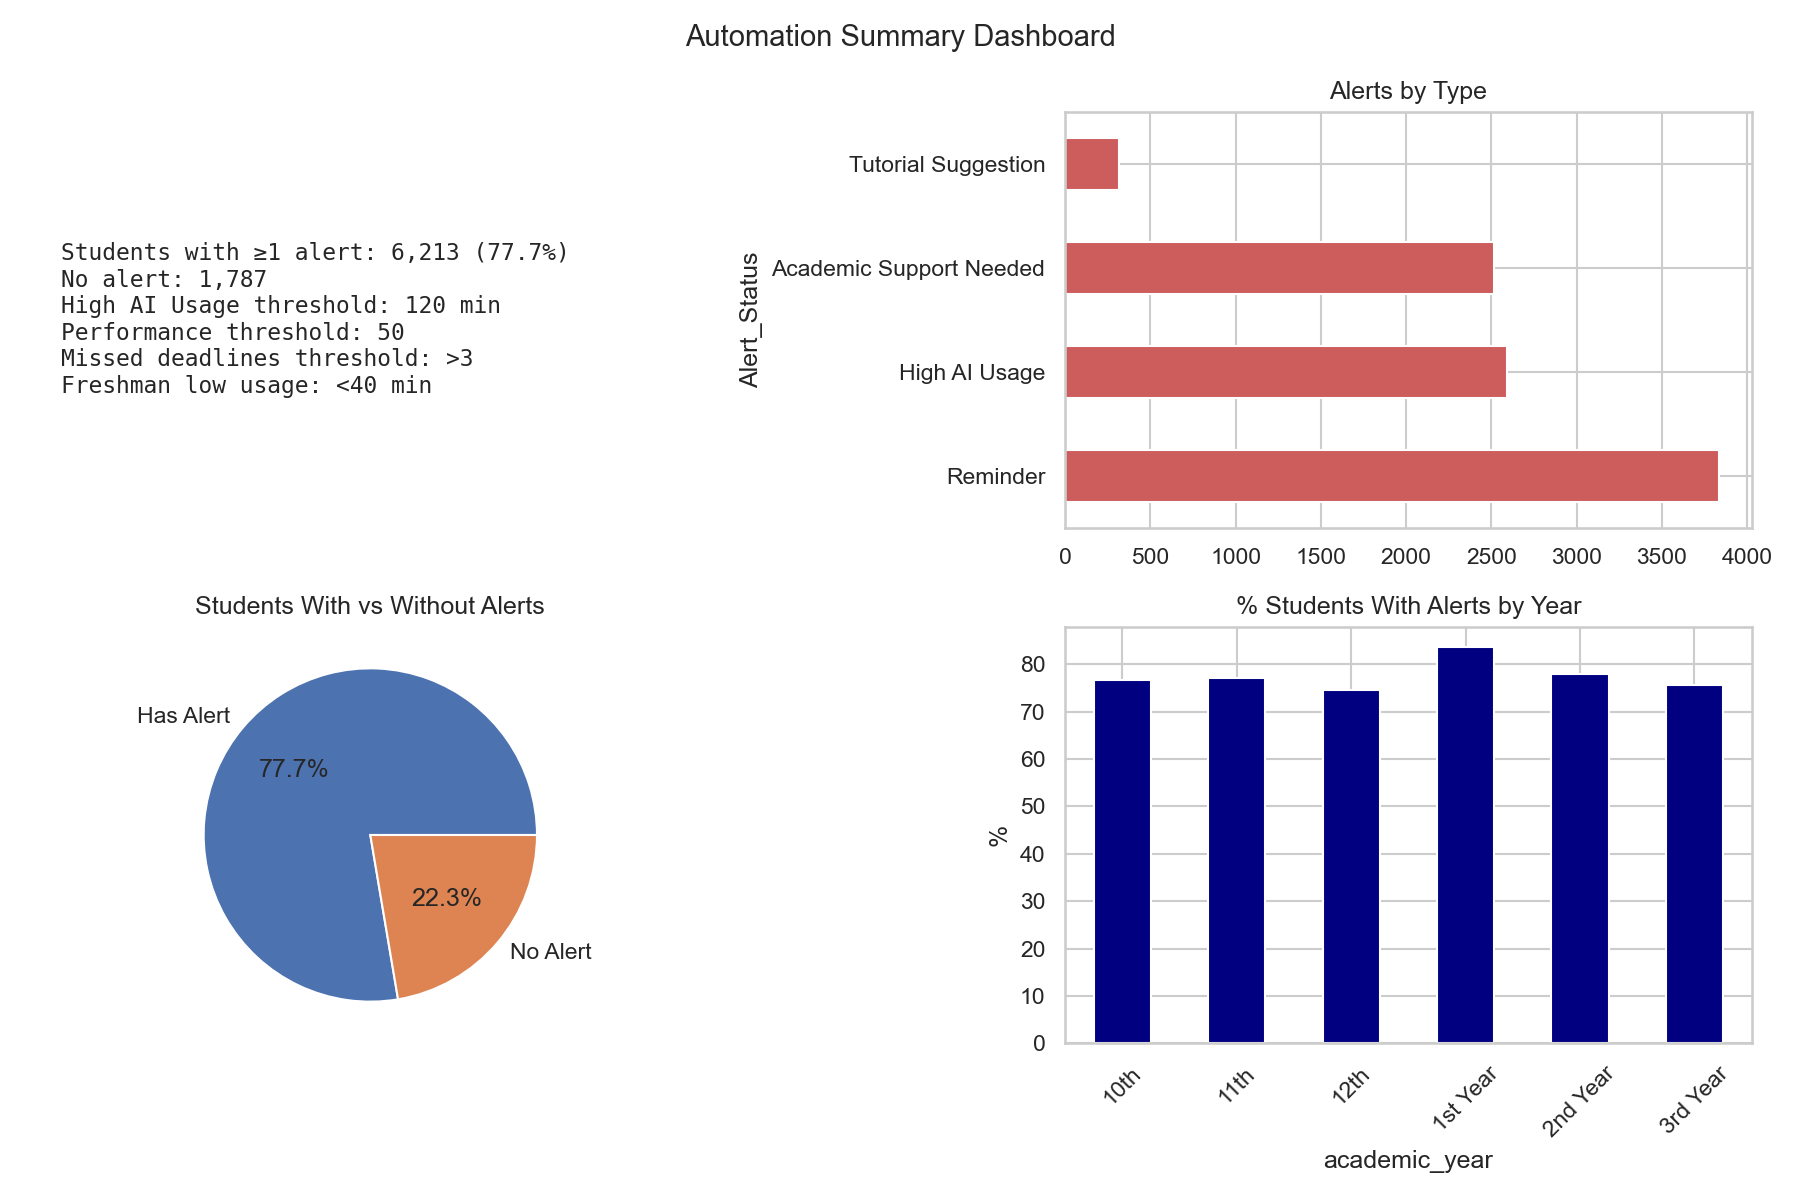


Visual report saved: /Users/nilufar/Desktop/AI Usage /ai-usage-analysis/output/analysis_report.html
HTML report: /Users/nilufar/Desktop/AI Usage /ai-usage-analysis/output/analysis_report.html


PosixPath('output/analysis_report.html')

In [11]:
out_csv = OUTPUT_DIR / "processed_students_with_alerts.csv"
df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")

display(Markdown("### Sample rows with Alert_Status"))
display(df[["student_id", "grade_level", "ai_usage_time_minutes", "final_score", "Alert_Status"]].head(10))

display(Markdown("### Alert summary"))
display(df["Alert_Status"].str.split("; ").explode().value_counts().to_frame("count"))

show_png_gallery(list(CHART_TITLES.keys()))

report_path = generate_html_report(
    df, results, load_meta, clean_meta,
    dataset_name=data_path.name,
    open_browser=False,
)
print(f"HTML report: {report_path.resolve()}")
report_path
